# Compare to Literature 

In [14]:
from pathlib import Path
import re
import zipfile
import xml.etree.ElementTree as ET

import pandas as pd

# ---------- Paths ----------
ko_path = "/user/home/il22158/work/vEcoli/surrogate/results/ko_runs_with_success_generation.csv"
essential_path = "/user/home/il22158/work/vEcoli/reading/imported/table s19_data.xlsx"
out_dir = Path("/user/home/il22158/work/vEcoli/surrogate/comparison")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "simulation_failure_compared_to_rosset_all_strains_M9.csv"


def _canon(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(s).strip().lower())


def _find_col(df: pd.DataFrame, target_key: str):
    cmap = {_canon(c): c for c in df.columns}
    if target_key in cmap:
        return cmap[target_key]
    for k, v in cmap.items():
        if target_key in k or k in target_key:
            return v
    return None


def read_xlsx_without_openpyxl(path: str) -> pd.DataFrame:
    """Read first worksheet from xlsx using stdlib xml parsing only."""
    ns = {"a": "http://schemas.openxmlformats.org/spreadsheetml/2006/main"}

    def col_to_idx(cell_ref: str) -> int:
        col = "".join(ch for ch in cell_ref if ch.isalpha())
        idx = 0
        for ch in col:
            idx = idx * 26 + (ord(ch.upper()) - ord("A") + 1)
        return idx - 1

    with zipfile.ZipFile(path) as zf:
        shared_strings = []
        if "xl/sharedStrings.xml" in zf.namelist():
            sroot = ET.fromstring(zf.read("xl/sharedStrings.xml"))
            for si in sroot.findall("a:si", ns):
                parts = [t.text or "" for t in si.findall(".//a:t", ns)]
                shared_strings.append("".join(parts))

        sheet_xml = ET.fromstring(zf.read("xl/worksheets/sheet1.xml"))
        parsed_rows = []
        for row in sheet_xml.findall(".//a:sheetData/a:row", ns):
            vals = {}
            for c in row.findall("a:c", ns):
                ref = c.attrib.get("r", "")
                if not ref:
                    continue
                cidx = col_to_idx(ref)
                ctype = c.attrib.get("t", "")
                v = c.find("a:v", ns)
                if v is None or v.text is None:
                    vals[cidx] = None
                    continue
                raw = v.text
                if ctype == "s":
                    vals[cidx] = shared_strings[int(raw)] if raw.isdigit() and int(raw) < len(shared_strings) else raw
                else:
                    vals[cidx] = raw
            parsed_rows.append(vals)

    if not parsed_rows:
        return pd.DataFrame()

    max_col = max((max(r.keys()) for r in parsed_rows if r), default=-1)
    if max_col < 0:
        return pd.DataFrame()

    grid = [[r.get(i, None) for i in range(max_col + 1)] for r in parsed_rows]

    # Auto-detect header row containing both required columns.
    header_idx = None
    for i, row in enumerate(grid[:20]):
        row_keys = {_canon(x) for x in row if x is not None and str(x).strip() != ""}
        if any("rnaid" == k or "rnaid" in k for k in row_keys) and any("roussetallstrainsm9" == k or "roussetallstrainsm9" in k for k in row_keys):
            header_idx = i
            break

    if header_idx is None:
        # fallback: skip first two rows as discussed
        header_idx = 2 if len(grid) > 2 else 0

    header = [str(x).strip() if x is not None else "" for x in grid[header_idx]]
    data = grid[header_idx + 1 :]
    df = pd.DataFrame(data, columns=header)
    df = df.dropna(axis=0, how="all").dropna(axis=1, how="all")
    return df


# ---------- Load data ----------
ko_df = pd.read_csv(ko_path)
ess_df = read_xlsx_without_openpyxl(essential_path)

# ---------- Normalize identifiers ----------
# Prefer explicit KO gene IDs in dataset 1; fallback to parsing "KO: ..." labels.
if "gene_id" in ko_df.columns and ko_df["gene_id"].notna().any():
    ko_df["gene_id"] = ko_df["gene_id"].astype(str).str.strip()
else:
    ko_df["gene_id"] = (
        ko_df["variant"]
        .astype(str)
        .str.replace(r"^KO:\s*", "", regex=True)
        .str.strip()
    )

rna_col = _find_col(ess_df, "rnaid")
rousset_col = _find_col(ess_df, "roussetallstrainsm9")
if rna_col is None or rousset_col is None:
    raise KeyError(f"Could not find RNA/Rousset columns in table s19_data.xlsx. Available: {list(ess_df.columns)}")

ess_df = ess_df.rename(columns={rna_col: "RNA ID", rousset_col: "Rousset_all_strains_M9"})

# RNA IDs look like "b1234_RNA" (or similar) -> keep base identifier.
ess_df["gene_id"] = (
    ess_df["RNA ID"]
    .astype(str)
    .str.replace(r"_RNA$", "", regex=True)
    .str.strip()
)

# ---------- Build KO-level failure flag ----------
# If any simulation for the same KO failed_before_gen8, mark KO as failed overall.
ko_df["failed_before_gen8"] = ko_df["failed_before_gen8"].fillna(False).astype(bool)
ko_by_gene = (
    ko_df.groupby("gene_id", as_index=False)
    .agg(
        failed_before_gen8=("failed_before_gen8", "max"),
        variant_example=("variant", "first"),
        n_simulations=("variant", "size"),
    )
)

# ---------- Keep essentiality labels from Table S19 ----------
ess_subset = ess_df[["gene_id", "RNA ID", "Rousset_all_strains_M9"]].drop_duplicates("gene_id")

# ---------- Compare ----------
comparison = ko_by_gene.merge(ess_subset, on="gene_id", how="left")
unmatched = comparison[comparison["RNA ID"].isna()].copy()
comparison_matched = comparison[comparison["RNA ID"].notna()].copy()

# Standardize Rousset label to bool.
def to_bool_like(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip().lower()
    if s in {"true", "1", "yes", "y", "essential", "failed"}:
        return True
    if s in {"false", "0", "no", "n", "non-essential", "nonessential", "unessential", "successful"}:
        return False
    return pd.NA

comparison_matched["rousset_bool"] = comparison_matched["Rousset_all_strains_M9"].map(to_bool_like)

# New explicit criterion:
# rousset_bool=True  -> expected essential -> expected simulation failure=True
# rousset_bool=False -> expected non-essential -> expected simulation failure=False
comparison_matched["expected_failed_before_gen8"] = comparison_matched["rousset_bool"]
comparison_matched["criteria_match"] = (
    comparison_matched["failed_before_gen8"] == comparison_matched["expected_failed_before_gen8"]
)
comparison_matched["expected_category"] = comparison_matched["rousset_bool"].map(
    lambda x: "expected_essential" if x is True else ("expected_nonessential" if x is False else "unknown")
)

# ---------- Final display table ----------
result_table = comparison_matched[
    [
        "variant_example",
        "gene_id",
        "failed_before_gen8",
        "expected_failed_before_gen8",
        "RNA ID",
        "Rousset_all_strains_M9",
        "rousset_bool",
        "expected_category",
        "criteria_match",
        "n_simulations",
    ]
].rename(columns={"variant_example": "variant"}).sort_values("variant")

result_table.to_csv(out_path, index=False)

print(f"Matched KO genes: {len(result_table)}")
print(f"Unmatched KO genes (exemptions): {len(unmatched)}")
print(f"Criteria matched rows: {int(result_table['criteria_match'].sum())}")
print(f"Saved comparison table: {out_path}")

if len(unmatched) > 0:
    print("\nExemptions (KO in dataset 1 not found in dataset 2):")
    print(
        unmatched[["variant_example", "gene_id", "failed_before_gen8", "n_simulations"]]
        .rename(columns={"variant_example": "variant"})
        .sort_values("variant")
        .to_string(index=False)
    )

result_table

Matched KO genes: 462
Unmatched KO genes (exemptions): 0
Criteria matched rows: 368
Saved comparison table: /user/home/il22158/work/vEcoli/surrogate/comparison/simulation_failure_compared_to_rosset_all_strains_M9.csv


,variant,gene_id,failed_before_gen8,expected_failed_before_gen8,RNA ID,Rousset_all_strains_M9,rousset_bool,expected_category,criteria_match,n_simulations
0,1,EG10001,False,False,EG10001_RNA,0,False,expected_nonessential,True,2
70,1,EG10109,False,False,EG10109_RNA,0,False,expected_nonessential,True,2
1,2,EG10004,False,True,EG10004_RNA,1,True,expected_essential,False,2
235,2,EG10894,True,False,EG10894_RNA,0,False,expected_nonessential,False,2
299,3,EG11288,False,False,EG11288_RNA,0,False,expected_nonessential,True,2
...,...,...,...,...,...,...,...,...,...,...
266,437,EG11001,True,True,EG11001_RNA,1,True,expected_essential,True,2
8,438,EG10023,False,False,EG10023_RNA,0,False,expected_nonessential,True,2
407,439,G6770,False,False,G6770_RNA,0,False,expected_nonessential,True,2
82,440,EG10131,False,False,EG10131_RNA,0,False,expected_nonessential,True,2


In [15]:
from pathlib import Path
import re
import zipfile
import xml.etree.ElementTree as ET

import pandas as pd

comparison_path = Path("/user/home/il22158/work/vEcoli/surrogate/comparison/simulation_failure_compared_to_rosset_all_strains_M9.csv")
process_xlsx_path = Path("/user/home/il22158/work/vEcoli/reading/imported/gene_process_label_data.xlsx")
out_path = Path("/user/home/il22158/work/vEcoli/surrogate/comparison/simulation_failure_disagreement_with_process_labels.csv")


def _canon(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(s).strip().lower())


def _find_col(df: pd.DataFrame, target_key: str):
    cmap = {_canon(c): c for c in df.columns}
    if target_key in cmap:
        return cmap[target_key]
    for k, v in cmap.items():
        if target_key in k or k in target_key:
            return v
    return None


def read_xlsx_without_openpyxl(path: str) -> pd.DataFrame:
    ns = {"a": "http://schemas.openxmlformats.org/spreadsheetml/2006/main"}

    def col_to_idx(cell_ref: str) -> int:
        col = "".join(ch for ch in cell_ref if ch.isalpha())
        idx = 0
        for ch in col:
            idx = idx * 26 + (ord(ch.upper()) - ord("A") + 1)
        return idx - 1

    with zipfile.ZipFile(path) as zf:
        shared_strings = []
        if "xl/sharedStrings.xml" in zf.namelist():
            sroot = ET.fromstring(zf.read("xl/sharedStrings.xml"))
            for si in sroot.findall("a:si", ns):
                parts = [t.text or "" for t in si.findall(".//a:t", ns)]
                shared_strings.append("".join(parts))

        sheet_xml = ET.fromstring(zf.read("xl/worksheets/sheet1.xml"))
        parsed_rows = []
        for row in sheet_xml.findall(".//a:sheetData/a:row", ns):
            vals = {}
            for c in row.findall("a:c", ns):
                ref = c.attrib.get("r", "")
                if not ref:
                    continue
                cidx = col_to_idx(ref)
                ctype = c.attrib.get("t", "")
                v = c.find("a:v", ns)
                if v is None or v.text is None:
                    vals[cidx] = None
                    continue
                raw = v.text
                if ctype == "s":
                    vals[cidx] = shared_strings[int(raw)] if raw.isdigit() and int(raw) < len(shared_strings) else raw
                else:
                    vals[cidx] = raw
            parsed_rows.append(vals)

    if not parsed_rows:
        return pd.DataFrame()

    max_col = max((max(r.keys()) for r in parsed_rows if r), default=-1)
    if max_col < 0:
        return pd.DataFrame()

    grid = [[r.get(i, None) for i in range(max_col + 1)] for r in parsed_rows]

    # Auto-detect header row containing RNA ID and Process.
    header_idx = None
    for i, row in enumerate(grid[:20]):
        row_keys = {_canon(x) for x in row if x is not None and str(x).strip() != ""}
        has_rna = any(k == "rnaid" or "rnaid" in k for k in row_keys)
        has_process = any(k == "process" or "process" in k for k in row_keys)
        if has_rna and has_process:
            header_idx = i
            break

    if header_idx is None:
        header_idx = 0

    header = [str(x).strip() if x is not None else "" for x in grid[header_idx]]
    data = grid[header_idx + 1 :]
    df = pd.DataFrame(data, columns=header)
    return df.dropna(axis=0, how="all").dropna(axis=1, how="all")


# 1) Load saved comparison table
comp = pd.read_csv(comparison_path)

# Support both older and newer column naming
if "agreement" in comp.columns:
    agreement_col = "agreement"
elif "criteria_match" in comp.columns:
    agreement_col = "criteria_match"
else:
    raise KeyError(f"No agreement column found. Available columns: {list(comp.columns)}")

comp[agreement_col] = comp[agreement_col].astype(bool)

n_total = len(comp)
failed_agreement = comp[~comp[agreement_col]].copy()
n_failed = len(failed_agreement)
print(f"Agreement failed for {n_failed} out of {n_total} KOs.")

# 2) Load process label table
proc_df = read_xlsx_without_openpyxl(str(process_xlsx_path))
rna_col = _find_col(proc_df, "rnaid")
process_col = _find_col(proc_df, "process")
if rna_col is None or process_col is None:
    raise KeyError(f"Could not find RNA ID / Process columns. Available: {list(proc_df.columns)}")

proc_df = proc_df.rename(columns={rna_col: "RNA ID", process_col: "Process"})
proc_df["gene_id"] = (
    proc_df["RNA ID"].astype(str).str.replace(r"_RNA$", "", regex=True).str.strip()
)
proc_df = proc_df[["gene_id", "RNA ID", "Process"]].drop_duplicates()

# 3) Join process labels to disagreement rows
failed_with_process = failed_agreement.merge(
    proc_df[["gene_id", "Process"]],
    on="gene_id",
    how="left",
)
failed_with_process["Process"] = failed_with_process["Process"].fillna("Unknown")

# 4) Add process percentage among disagreement rows
process_counts = failed_with_process["Process"].value_counts(dropna=False)
process_share = (process_counts / max(len(failed_with_process), 1) * 100.0).rename("process_percent_of_disagreement")
failed_with_process = failed_with_process.merge(
    process_share.reset_index().rename(columns={"index": "Process"}),
    on="Process",
    how="left",
)

# 5) Save table (only disagreement genes + process label + share)
# Keep key columns first, then retain remaining columns for traceability.
preferred_cols = [
    "variant",
    "gene_id",
    "RNA ID",
    "failed_before_gen8",
    agreement_col,
    "Process",
    "process_percent_of_disagreement",
]
final_cols = [c for c in preferred_cols if c in failed_with_process.columns] + [
    c for c in failed_with_process.columns if c not in preferred_cols
]
failed_with_process = failed_with_process[final_cols]
failed_with_process.to_csv(out_path, index=False)

print(f"Saved disagreement-process table: {out_path}")
failed_with_process

Agreement failed for 94 out of 462 KOs.
Saved disagreement-process table: /user/home/il22158/work/vEcoli/surrogate/comparison/simulation_failure_disagreement_with_process_labels.csv


,variant,gene_id,RNA ID,failed_before_gen8,criteria_match,Process,process_percent_of_disagreement,expected_failed_before_gen8,Rousset_all_strains_M9,rousset_bool,expected_category,n_simulations
0,2,EG10004,EG10004_RNA,False,False,Metabolism,85.106383,True,1,True,expected_essential,2
1,2,EG10894,EG10894_RNA,True,False,Transcription,2.127660,False,0,False,expected_nonessential,2
2,5,EG10032,EG10032_RNA,False,False,Metabolism,85.106383,True,1,True,expected_essential,2
3,7,EG10017,EG10017_RNA,False,False,Metabolism,85.106383,True,1,True,expected_essential,2
4,7,EG10891,EG10891_RNA,True,False,Translation,11.702128,False,0,False,expected_nonessential,2
...,...,...,...,...,...,...,...,...,...,...,...,...
89,414,EG10185,EG10185_RNA,False,False,Metabolism,85.106383,True,1,True,expected_essential,2
90,421,EG10449,EG10449_RNA,True,False,Metabolism,85.106383,False,0,False,expected_nonessential,2
91,422,EG10946,EG10946_RNA,False,False,Metabolism,85.106383,True,1,True,expected_essential,2
92,427,EG10965,EG10965_RNA,False,False,Metabolism,85.106383,True,1,True,expected_essential,2


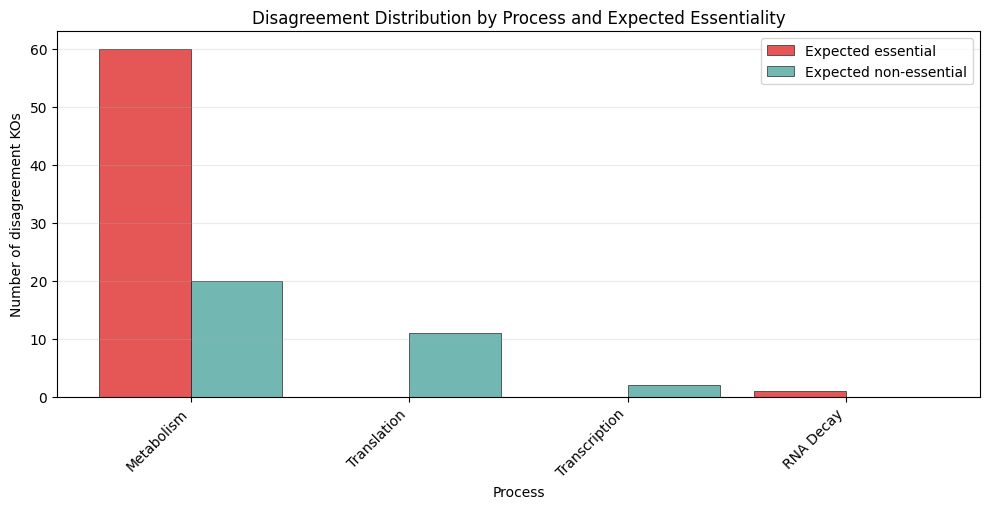

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load disagreement-only table saved in previous step
failed_tbl_path = Path(
    "/user/home/il22158/work/vEcoli/surrogate/comparison/"
    "simulation_failure_disagreement_with_process_labels.csv"
)
failed_tbl = pd.read_csv(failed_tbl_path)

# Build expected class column
if "expected_category" in failed_tbl.columns:
    cat_series = failed_tbl["expected_category"].fillna("unknown")
else:
    cat_series = failed_tbl["expected_failed_before_gen8"].map(
        lambda x: "expected_essential" if bool(x) else "expected_nonessential"
    )

plot_df = failed_tbl.copy()
plot_df["expected_category"] = cat_series

# Keep only the two requested classes for side-by-side comparison
valid_classes = ["expected_essential", "expected_nonessential"]
plot_df = plot_df[plot_df["expected_category"].isin(valid_classes)].copy()
plot_df["Process"] = plot_df["Process"].fillna("Unknown")

# Count disagreement KOs by process and expected class
counts = (
    plot_df.groupby(["Process", "expected_category"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=valid_classes, fill_value=0)
)

# Sort processes by total disagreement count (descending)
counts = counts.assign(_total=counts.sum(axis=1)).sort_values("_total", ascending=False).drop(columns=["_total"])

# Grouped bar plot: adjacent bars for essential vs non-essential within each process
x = np.arange(len(counts.index))
bar_w = 0.42

plt.figure(figsize=(max(10, 0.42 * len(counts.index) + 4), 5.2))
plt.bar(
    x - bar_w / 2,
    counts["expected_essential"].values,
    width=bar_w,
    color="#E45756",
    edgecolor="black",
    linewidth=0.4,
    label="Expected essential",
)
plt.bar(
    x + bar_w / 2,
    counts["expected_nonessential"].values,
    width=bar_w,
    color="#72B7B2",
    edgecolor="black",
    linewidth=0.4,
    label="Expected non-essential",
)

plt.title("Disagreement Distribution by Process and Expected Essentiality")
plt.xlabel("Process")
plt.ylabel("Number of disagreement KOs")
plt.xticks(x, counts.index, rotation=45, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(failed_tbl_path.parent / "disagreement_by_process_and_category.png")
plt.show()

# Distribution of failed and successful simulations

**Procedure**

- Keep all KO variants in the analysis, including those that failed before generation 8.
- Build failure labels from folder existence under out/{project}/success/.../generation=8 (missing folder = failed).
- Use baseline rows strictly from all_media_conditions* with variant=0 and label=baseline.
- Compute each run's growth-rate ratio relative to its seed baseline.
- Compare successful vs failed runs with scatter, box, and overlapping histogram+KDE plots before thresholding.

**KDE Method Explanation**

KDE is used in Plot 3 of Cell 4 to overlay smooth density curves on top of the success/failure histograms of mean growth-rate ratio.

Estimator used
For each group (Reached Gen8 and Failed < Gen8), the notebook estimates density with a Gaussian kernel:
$$\hat{f}(x)=\frac{1}{n h}\sum_{i=1}^{n} K\left(\frac{x-x_i}{h}\right),\quad K(u)=\frac{1}{\sqrt{2\pi}}e^{-u^2/2}$$

Implementation details in code
- Library: sklearn.neighbors.KernelDensity
- Kernel: gaussian
- Evaluation grid: 300 points between the global min and max of all growth-rate ratios (both groups combined).
- Preprocessing: values are converted to float and NaN values are removed before fitting.

Bandwidth choice
- Primary rule: Silverman-style rule of thumb
$$h = 1.06\,\sigma\,n^{-1/5}$$
where $\sigma$ is sample standard deviation and $n$ is group sample size.
- Fallback when variance is zero: use h = 0.05.
- Numerical floor: h is clipped to at least 1e-3.

Assumptions and consequences
- KDE is non-parametric: it does not assume a normal distribution for growth-rate ratios.
- Smoothness is controlled by bandwidth h; larger h gives smoother curves, smaller h gives noisier curves.
- The same kernel family (Gaussian) is used for both groups for fair visual comparison.
- If a group has fewer than 2 valid points, the code returns a zero-density curve (no meaningful KDE fit).
- Histograms are plotted with density=True and 30 bins, so histogram area and KDE curves are on comparable density scale.

## Inspect with data summaries

**Data**
- gene list:
/user/home/il22158/work/vEcoli/reading/imported/Single_KO_RNA_names.txt

- growth-rate summaries:
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_441_KOs_seed100_all.csv
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_441_KOs_seed101_all.csv
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_seed100_all.csv
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_seed101_all.csv
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_default_all.csv

- explanation:
1. the single-knockout variants are saved in all four csv files, and the baseline simulation are the one labelled as baseline under "all media conditions..." simulation folder.
2. 2 baseline simulation (wildtype) can be found in /user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_seed100_all.csv and /user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_default_all.csv.

### Distogram of last generation

Table: KO run counts by last/longest generation (1-8).


,last_generation,n_runs
0,1,0
1,2,0
2,3,7
3,4,42
4,5,98
5,6,54
6,7,21
7,8,702


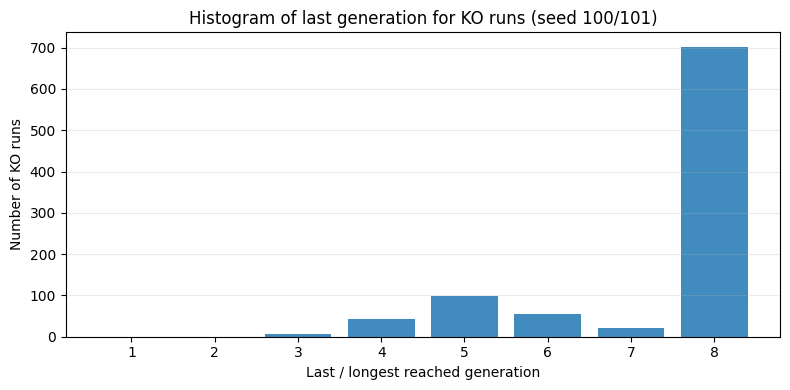

In [20]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Build histogram of last generation from existing KO detail output
# -------------------------
OUT_DIR = Path('/user/home/il22158/work/vEcoli/surrogate/results')
OUT_DIR.mkdir(parents=True, exist_ok=True)

KO_DETAIL_PATH = OUT_DIR / 'ko_runs_with_success_generation.csv'
if not KO_DETAIL_PATH.exists():
    raise FileNotFoundError(
        f'Missing required file: {KO_DETAIL_PATH}. Run the KO summary cell first.'
    )

ko_df = pd.read_csv(KO_DETAIL_PATH)
required_cols = ['project', 'variant', 'lineage_seed']
for c in required_cols:
    if c not in ko_df.columns:
        raise KeyError(f"Column '{c}' not found in {KO_DETAIL_PATH}. Available columns: {list(ko_df.columns)}")

ko_df['lineage_seed'] = pd.to_numeric(ko_df['lineage_seed'], errors='coerce').astype('Int64')
ko_df['variant'] = pd.to_numeric(ko_df['variant'], errors='coerce').astype('Int64')

# KO-only seed scope requested: keep 100/101 (baseline seed 0 excluded)
ko_df = ko_df[ko_df['lineage_seed'].isin([100, 101])].copy()

# One row per KO simulation run
run_keys = (
    ko_df[['project', 'variant', 'lineage_seed', 'gene_id', 'max_success_generation']]
    .dropna(subset=['project', 'variant', 'lineage_seed'])
    .copy()
)

# If max_success_generation is missing, rebuild from folders
if 'max_success_generation' not in run_keys.columns or run_keys['max_success_generation'].isna().all():
    OUT_ROOT = Path('/user/home/il22158/work/vEcoli/out')

    def generation_dir(project: str, variant: int, lineage_seed: int, generation: int) -> Path:
        return (
            OUT_ROOT
            / str(project)
            / 'success'
            / f'experiment_id={project}'
            / f'variant={int(variant)}'
            / f'lineage_seed={int(lineage_seed)}'
            / f'generation={int(generation)}'
        )

    def max_existing_generation(project: str, variant: int, lineage_seed: int, max_gen: int = 8) -> int:
        for g in range(max_gen, 0, -1):
            if generation_dir(project, variant, lineage_seed, g).exists():
                return g
        return 0

    base_runs = run_keys[['project', 'variant', 'lineage_seed', 'gene_id']].drop_duplicates().copy()
    base_runs['project'] = base_runs['project'].astype(str)
    base_runs['variant'] = base_runs['variant'].astype(int)
    base_runs['lineage_seed'] = base_runs['lineage_seed'].astype(int)
    base_runs['max_success_generation'] = [
        max_existing_generation(r.project, r.variant, r.lineage_seed, max_gen=8)
        for r in base_runs.itertuples(index=False)
    ]
    run_keys = base_runs
else:
    run_keys['max_success_generation'] = pd.to_numeric(run_keys['max_success_generation'], errors='coerce').fillna(0).astype(int)
    run_keys = run_keys[['project', 'variant', 'lineage_seed', 'gene_id', 'max_success_generation']].drop_duplicates().copy()

# Histogram for generation 1..8
hist_df = run_keys[run_keys['max_success_generation'].between(1, 8)].copy()
missing_all = int((run_keys['max_success_generation'] == 0).sum())
if missing_all > 0:
    print(f'Runs with no detected success generation folder (0): {missing_all}')

counts = (
    hist_df['max_success_generation']
    .value_counts()
    .reindex(range(1, 9), fill_value=0)
    .rename_axis('last_generation')
    .reset_index(name='n_runs')
)

print('Table: KO run counts by last/longest generation (1-8).')
display(counts)

plt.figure(figsize=(8, 4))
plt.bar(counts['last_generation'], counts['n_runs'], color='#1f77b4', alpha=0.85)
plt.xticks(range(1, 9))
plt.xlabel('Last / longest reached generation')
plt.ylabel('Number of KO runs')
plt.title('Histogram of last generation for KO runs (seed 100/101)')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

Table: KO run counts by last/longest generation (1-7).


,last_generation,n_runs
0,1,0
1,2,0
2,3,7
3,4,42
4,5,98
5,6,54
6,7,21


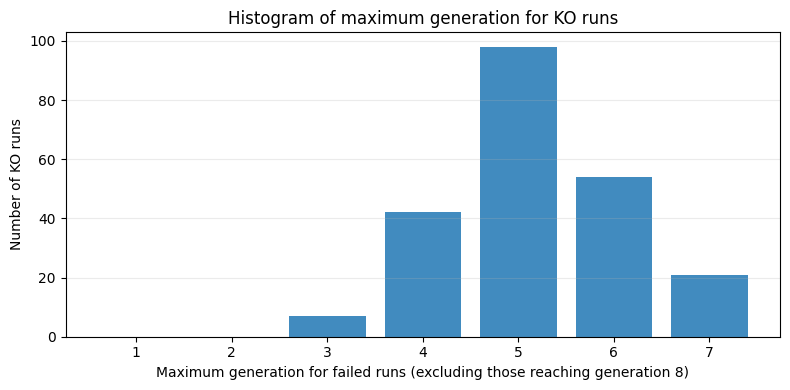

In [21]:
"""Same plot bot excluding the ones successfully reaching generation 8, to focus on the earlier failures"""
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Build histogram of last generation from existing KO detail output
# -------------------------
OUT_DIR = Path('/user/home/il22158/work/vEcoli/surrogate/results')
OUT_DIR.mkdir(parents=True, exist_ok=True)

KO_DETAIL_PATH = OUT_DIR / 'ko_runs_with_success_generation.csv'
if not KO_DETAIL_PATH.exists():
    raise FileNotFoundError(
        f'Missing required file: {KO_DETAIL_PATH}. Run the KO summary cell first.'
    )

ko_df = pd.read_csv(KO_DETAIL_PATH)
required_cols = ['project', 'variant', 'lineage_seed']
for c in required_cols:
    if c not in ko_df.columns:
        raise KeyError(f"Column '{c}' not found in {KO_DETAIL_PATH}. Available columns: {list(ko_df.columns)}")

ko_df['lineage_seed'] = pd.to_numeric(ko_df['lineage_seed'], errors='coerce').astype('Int64')
ko_df['variant'] = pd.to_numeric(ko_df['variant'], errors='coerce').astype('Int64')

# KO-only seed scope requested: keep 100/101 (baseline seed 0 excluded)
ko_df = ko_df[ko_df['lineage_seed'].isin([100, 101])].copy()

# One row per KO simulation run
run_keys = (
    ko_df[['project', 'variant', 'lineage_seed', 'gene_id', 'max_success_generation']]
    .dropna(subset=['project', 'variant', 'lineage_seed'])
    .copy()
)

# If max_success_generation is missing, rebuild from folders
if 'max_success_generation' not in run_keys.columns or run_keys['max_success_generation'].isna().all():
    OUT_ROOT = Path('/user/home/il22158/work/vEcoli/out')

    def generation_dir(project: str, variant: int, lineage_seed: int, generation: int) -> Path:
        return (
            OUT_ROOT
            / str(project)
            / 'success'
            / f'experiment_id={project}'
            / f'variant={int(variant)}'
            / f'lineage_seed={int(lineage_seed)}'
            / f'generation={int(generation)}'
        )

    def max_existing_generation(project: str, variant: int, lineage_seed: int, max_gen: int = 8) -> int:
        for g in range(max_gen, 0, -1):
            if generation_dir(project, variant, lineage_seed, g).exists():
                return g
        return 0

    base_runs = run_keys[['project', 'variant', 'lineage_seed', 'gene_id']].drop_duplicates().copy()
    base_runs['project'] = base_runs['project'].astype(str)
    base_runs['variant'] = base_runs['variant'].astype(int)
    base_runs['lineage_seed'] = base_runs['lineage_seed'].astype(int)
    base_runs['max_success_generation'] = [
        max_existing_generation(r.project, r.variant, r.lineage_seed, max_gen=8)
        for r in base_runs.itertuples(index=False)
    ]
    run_keys = base_runs
else:
    run_keys['max_success_generation'] = pd.to_numeric(run_keys['max_success_generation'], errors='coerce').fillna(0).astype(int)
    run_keys = run_keys[['project', 'variant', 'lineage_seed', 'gene_id', 'max_success_generation']].drop_duplicates().copy()

# Histogram for generation 1..8
hist_df = run_keys[run_keys['max_success_generation'].between(1, 7)].copy()
missing_all = int((run_keys['max_success_generation'] == 0).sum())
if missing_all > 0:
    print(f'Runs with no detected success generation folder (0): {missing_all}')

counts = (
    hist_df['max_success_generation']
    .value_counts()
    .reindex(range(1, 8), fill_value=0)
    .rename_axis('last_generation')
    .reset_index(name='n_runs')
)

print('Table: KO run counts by last/longest generation (1-7).')
display(counts)

plt.figure(figsize=(8, 4))
plt.bar(counts['last_generation'], counts['n_runs'], color='#1f77b4', alpha=0.85)
plt.xticks(range(1, 8))
plt.xlabel('Maximum generation for failed runs (excluding those reaching generation 8)')
plt.ylabel('Number of KO runs')
plt.title('Histogram of maximum generation for KO runs')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / 'ko_run_last_generation_histogram_excluding_gen8.png')
plt.show()

### Distogram of mean growth rate and mass fold change

In [22]:
from pathlib import Path

import numpy as np
import pandas as pd

# -------------------------
# Inspect growth-rate unit from raw simulation data and convert to per-hour
# -------------------------
OUT_ROOT = Path('/user/home/il22158/work/vEcoli/out')
OUT_DIR = Path('/user/home/il22158/work/vEcoli/surrogate/results')
OUT_DIR.mkdir(parents=True, exist_ok=True)

KO_DETAIL_PATH = OUT_DIR / 'ko_runs_with_success_generation.csv'
if not KO_DETAIL_PATH.exists():
    raise FileNotFoundError(
        f'Missing {KO_DETAIL_PATH}. Run the KO summary analysis cell first.'
    )

ko_detail = pd.read_csv(KO_DETAIL_PATH)
required_cols = ['project', 'variant', 'lineage_seed']
missing_cols = [c for c in required_cols if c not in ko_detail.columns]
if missing_cols:
    raise KeyError(f'Missing columns in {KO_DETAIL_PATH}: {missing_cols}')

# Keep KO run seeds only (100, 101)
ko_detail['lineage_seed'] = pd.to_numeric(ko_detail['lineage_seed'], errors='coerce')
ko_detail['variant'] = pd.to_numeric(ko_detail['variant'], errors='coerce')
ko_runs = ko_detail[ko_detail['lineage_seed'].isin([100, 101])].dropna(subset=['project', 'variant', 'lineage_seed']).copy()
if ko_runs.empty:
    raise RuntimeError('No KO runs found for lineage_seed in [100, 101].')

sample = ko_runs[['project', 'variant', 'lineage_seed']].drop_duplicates().iloc[0]
project = str(sample['project'])
variant = int(sample['variant'])
lineage_seed = int(sample['lineage_seed'])

raw_base = (
    OUT_ROOT
    / project
    / 'history'
    / f'experiment_id={project}'
    / f'variant={variant}'
    / f'lineage_seed={lineage_seed}'
)
raw_files = sorted(raw_base.glob('generation=*/agent_id=*/**/*.pq'))
if not raw_files:
    raise RuntimeError(f'No raw pq files found under: {raw_base}')

raw_df = pd.read_parquet(raw_files[0])
if 'time' not in raw_df.columns or 'listeners__mass__instantaneous_growth_rate' not in raw_df.columns:
    raise KeyError(
        "Raw pq file missing required columns 'time' and/or 'listeners__mass__instantaneous_growth_rate'."
    )

time_s = pd.to_numeric(raw_df['time'], errors='coerce')
inst_rate = pd.to_numeric(raw_df['listeners__mass__instantaneous_growth_rate'], errors='coerce')

dt = np.diff(time_s.dropna().values)
dt = dt[np.isfinite(dt) & (dt > 0)]
median_dt = float(np.median(dt)) if len(dt) > 0 else np.nan

# Consistency check against d(log(mass))/dt when dry mass is available
ratio_msg = 'Dry-mass consistency check not available.'
if 'listeners__mass__dry_mass' in raw_df.columns:
    dry_mass = pd.to_numeric(raw_df['listeners__mass__dry_mass'], errors='coerce').values
    t = time_s.values
    r = inst_rate.values
    valid = np.isfinite(dry_mass) & (dry_mass > 0) & np.isfinite(t) & np.isfinite(r)
    dry_mass = dry_mass[valid]
    t = t[valid]
    r = r[valid]
    if len(dry_mass) >= 3:
        dlogm = np.diff(np.log(dry_mass))
        dt_local = np.diff(t)
        empirical = np.divide(dlogm, dt_local, out=np.full_like(dlogm, np.nan, dtype=float), where=dt_local > 0)
        common = np.isfinite(empirical) & np.isfinite(r[1:])
        if common.any():
            med_ratio = float(np.nanmedian(r[1:][common] / empirical[common]))
            ratio_msg = f"Median(inst_rate / dlogM_dt) = {med_ratio:.3f} (near 1 means inst_rate is in 1/time-unit)."

# Infer conversion to per-hour
median_abs_rate = float(np.nanmedian(np.abs(inst_rate.values[np.isfinite(inst_rate.values)])))
if 0.02 <= median_abs_rate <= 10:
    unit_guess = 'already_per_hour'
    to_per_hour = 1.0
elif 0.00001 <= median_abs_rate < 0.02:
    # Typical for 1/s growth rates in bacterial simulations
    unit_guess = 'per_second'
    to_per_hour = 3600.0
else:
    # Conservative fallback for ambiguous magnitudes
    unit_guess = 'assume_per_second'
    to_per_hour = 3600.0

print(f'Sample run for unit inspection: project={project}, variant={variant}, seed={lineage_seed}')
print(f'Sample raw file: {raw_files[0]}')
print(f'Median simulation dt from raw file: {median_dt:.3f}')
print(f'Median |instantaneous_growth_rate| in raw file: {median_abs_rate:.6g}')
print(ratio_msg)
print(f'Unit guess: {unit_guess}; conversion factor to per-hour = {to_per_hour}')

# Convert growth-rate columns used in previous analysis
if 'mean_growth_rate' in ko_detail.columns:
    ko_detail['mean_growth_rate_per_hr'] = pd.to_numeric(ko_detail['mean_growth_rate'], errors='coerce') * to_per_hour
if 'seed_baseline_mean_growth_rate' in ko_detail.columns:
    ko_detail['seed_baseline_mean_growth_rate_per_hr'] = (
        pd.to_numeric(ko_detail['seed_baseline_mean_growth_rate'], errors='coerce') * to_per_hour
    )

# Ratios are dimensionless and remain unchanged
out_path = OUT_DIR / 'ko_runs_with_success_generation_per_hr.csv'
ko_detail.to_csv(out_path, index=False)
print(f'Saved converted table: {out_path}')

show_cols = [c for c in [
    'project',
    'variant',
    'lineage_seed',
    'mean_growth_rate',
    'mean_growth_rate_per_hr',
    'seed_baseline_mean_growth_rate',
    'seed_baseline_mean_growth_rate_per_hr',
    'mean_growth_rate_ratio',
    'max_success_generation',
] if c in ko_detail.columns]

print('Preview of converted values:')
display(ko_detail[show_cols].head(10))

Sample run for unit inspection: project=gene_ko_441imported_2seeds, variant=1, seed=100
Sample raw file: /user/home/il22158/work/vEcoli/out/gene_ko_441imported_2seeds/history/experiment_id=gene_ko_441imported_2seeds/variant=1/lineage_seed=100/generation=1/agent_id=0/204.pq
Median simulation dt from raw file: 20.000
Median |instantaneous_growth_rate| in raw file: 0.000276136
Median(inst_rate / dlogM_dt) = 1.001 (near 1 means inst_rate is in 1/time-unit).
Unit guess: per_second; conversion factor to per-hour = 3600.0
Saved converted table: /user/home/il22158/work/vEcoli/surrogate/results/ko_runs_with_success_generation_per_hr.csv
Preview of converted values:


,project,variant,lineage_seed,mean_growth_rate,mean_growth_rate_per_hr,seed_baseline_mean_growth_rate,seed_baseline_mean_growth_rate_per_hr,mean_growth_rate_ratio,max_success_generation
0,gene_ko_441imported_2seeds,1,100,0.000189,0.680705,0.000231,0.830272,0.819858,8
1,gene_ko_441imported_2seeds,2,100,0.000152,0.546511,0.000231,0.830272,0.658231,5
2,gene_ko_441imported_2seeds,3,100,0.000192,0.690630,0.000231,0.830272,0.831812,8
3,gene_ko_441imported_2seeds,4,100,0.000193,0.694245,0.000231,0.830272,0.836166,8
4,gene_ko_441imported_2seeds,5,100,0.000211,0.758633,0.000231,0.830272,0.913717,8
5,gene_ko_441imported_2seeds,6,100,0.000087,0.313414,0.000231,0.830272,0.377483,3
6,gene_ko_441imported_2seeds,7,100,0.000310,1.116969,0.000231,0.830272,1.345305,4
7,gene_ko_441imported_2seeds,8,100,0.000213,0.765255,0.000231,0.830272,0.921692,6
8,gene_ko_441imported_2seeds,9,100,0.000208,0.747315,0.000231,0.830272,0.900084,8
9,gene_ko_441imported_2seeds,10,100,0.000190,0.685179,0.000231,0.830272,0.825247,8


KO samples used: 924
Data range: min=0.2715, max=2.2175 (1/hr)
Centered axis: center=1.2445, xmin=0.2445, xmax=2.2445, bin_step=0.05, label_step=0.25
Table: number of simulations in each growth-rate bin.


,bin_left,bin_right,bin_center,n_simulations
0,0.174,0.225,0.1995,0
1,0.225,0.275,0.2500,4
2,0.275,0.325,0.3000,32
3,0.325,0.375,0.3500,48
4,0.375,0.425,0.4000,30
5,0.425,0.475,0.4500,7
6,0.475,0.525,0.5000,7
7,0.525,0.575,0.5500,9
8,0.575,0.625,0.6000,1
9,0.625,0.675,0.6500,56


Bins with exactly 1 run: 9 | bins with 2-3 runs: 1


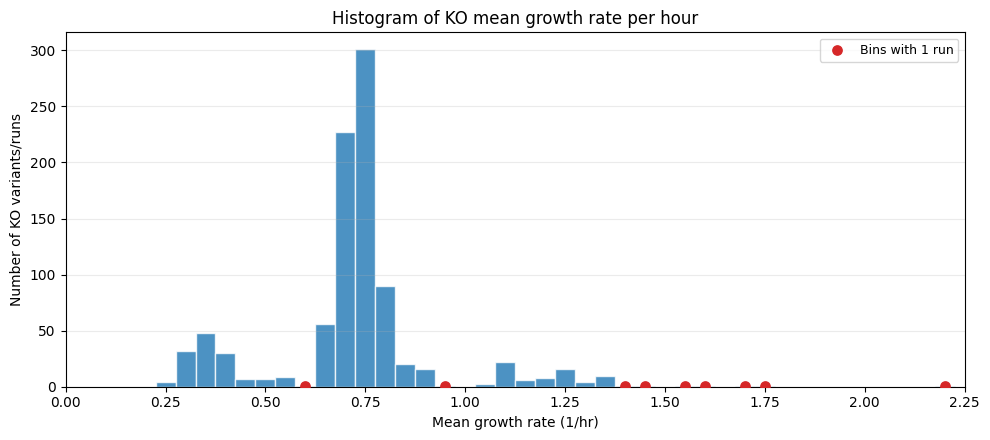

In [35]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Histogram of KO mean growth rate in per-hour unit
OUT_DIR = Path('/user/home/il22158/work/vEcoli/surrogate/results')
PER_HR_PATH = OUT_DIR / 'ko_runs_with_success_generation_per_hr.csv'
BASE_PATH = OUT_DIR / 'ko_runs_with_success_generation.csv'

if PER_HR_PATH.exists():
    df = pd.read_csv(PER_HR_PATH)
elif BASE_PATH.exists():
    df = pd.read_csv(BASE_PATH)
    if 'mean_growth_rate' not in df.columns:
        raise KeyError(f"'mean_growth_rate' not found in {BASE_PATH}")
    # Fallback conversion from 1/s to 1/hr when per-hour file is not yet generated.
    df['mean_growth_rate_per_hr'] = pd.to_numeric(df['mean_growth_rate'], errors='coerce') * 3600.0
    print('Info: per-hour file not found; converted mean_growth_rate to per hour using x3600.')
else:
    raise FileNotFoundError(f'Neither {PER_HR_PATH} nor {BASE_PATH} exists.')

if 'mean_growth_rate_per_hr' not in df.columns:
    raise KeyError("'mean_growth_rate_per_hr' column is required.")

# KO seed scope used in previous analysis
if 'lineage_seed' in df.columns:
    seed_num = pd.to_numeric(df['lineage_seed'], errors='coerce')
    df = df[seed_num.isin([100, 101])].copy()

x = pd.to_numeric(df['mean_growth_rate_per_hr'], errors='coerce').dropna()
x = x[np.isfinite(x)]
if x.empty:
    raise RuntimeError('No valid mean_growth_rate_per_hr values found for plotting.')

x_min = float(x.min())
x_max = float(x.max())
x_center = 0.5 * (x_min + x_max)

step = 0.05
half_span = max(x_center - x_min, x_max - x_center)
half_span_aligned = np.ceil(half_span / step) * step
xmin_plot = x_center - half_span_aligned
xmax_plot = x_center + half_span_aligned

# Bin edges so that bin centers align to 0.05 grid
center_anchor = np.round(x_center / step) * step
left_center = center_anchor + np.floor((xmin_plot - center_anchor) / step) * step
right_center = center_anchor + np.ceil((xmax_plot - center_anchor) / step) * step
centers = np.arange(left_center, right_center + 0.05 * step, step)
bin_edges = np.r_[centers - step / 2, centers[-1] + step / 2]

# Show x-axis labels in wider spacing for readability
tick_step = 0.25
tick_start = np.floor(xmin_plot / tick_step) * tick_step
tick_end = np.ceil(xmax_plot / tick_step) * tick_step
x_ticks = np.arange(tick_start, tick_end + 0.5 * tick_step, tick_step)

# Table: number of simulations in each histogram bin
bin_cats = pd.cut(x, bins=bin_edges, include_lowest=True, right=True)
bin_counts = bin_cats.value_counts(sort=False).reset_index()
bin_counts.columns = ['bin_interval', 'n_simulations']
bin_counts['bin_left'] = bin_counts['bin_interval'].map(lambda iv: iv.left).astype(float)
bin_counts['bin_right'] = bin_counts['bin_interval'].map(lambda iv: iv.right).astype(float)
bin_counts['bin_center'] = ((bin_counts['bin_left'] + bin_counts['bin_right']) / 2.0).astype(float)
bin_counts = bin_counts[['bin_left', 'bin_right', 'bin_center', 'n_simulations']]

# Highlight sparse bins so count=1 bars are visible on top of high-count bins
single_bins = bin_counts[bin_counts['n_simulations'] == 1].copy()
few_bins = bin_counts[(bin_counts['n_simulations'] > 1) & (bin_counts['n_simulations'] <= 3)].copy()

print(f'KO samples used: {len(x)}')
print(f'Data range: min={x_min:.4f}, max={x_max:.4f} (1/hr)')
print(f'Centered axis: center={x_center:.4f}, xmin={xmin_plot:.4f}, xmax={xmax_plot:.4f}, bin_step={step}, label_step={tick_step}')
print('Table: number of simulations in each growth-rate bin.')
display(bin_counts)
print(f'Bins with exactly 1 run: {len(single_bins)} | bins with 2-3 runs: {len(few_bins)}')

plt.figure(figsize=(10, 4.5))
plt.hist(x.values, bins=bin_edges, color='#1f77b4', alpha=0.8, edgecolor='white')

if len(single_bins) > 0:
    plt.scatter(
        single_bins['bin_center'].values,
        single_bins['n_simulations'].values,
        color='#d62728',
        s=45,
        marker='o',
        zorder=4,
        label='Bins with 1 run',
    )
# if len(few_bins) > 0:
#     plt.scatter(
#         few_bins['bin_center'].values,
#         few_bins['n_simulations'].values,
#         color='#ff7f0e',
#         s=35,
#         marker='^',
#         zorder=4,
#         label='Bins with 2-3 runs',
#     )

plt.xlim(xmin_plot, xmax_plot)
plt.xticks(x_ticks)
plt.xlabel('Mean growth rate (1/hr)')
plt.ylabel('Number of KO variants/runs')
plt.title('Histogram of KO mean growth rate per hour')
if (len(single_bins) > 0) or (len(few_bins) > 0):
    plt.legend(loc='upper right', fontsize=9)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / 'ko_mean_growth_rate_per_hr_histogram.png')
plt.show()

Expected KO genes from list: 462
Observed KO genes in summaries (after list filter): 462
Table: baseline growth-rate reference by lineage seed (0 and 100).


,lineage_seed,seed_baseline_mean_growth_rate
0,0,0.000226
1,100,0.000235


Holistic baseline mean growth rate (mean of seeds 0 and 100): 0.000231
Loaded KO rows: 924
Unique KO genes (final): 462
Runs with generation=8 folder: 702 / 924
Failure rate (run-level): 0.2403
Failure rate (gene-level any-seed): 0.2532
Table: gene-level aggregate summary of KO growth and failure statistics across runs/seeds.


,gene_id,mean_growth_rate,mean_growth_rate_ratio,std_growth_rate,failed_before_gen8,fail_rate,n_runs,mean_success_generation
0,EG10001,0.000230,0.997648,0.000005,0,0.0,2,8.0
1,EG10004,0.000238,1.033866,0.000003,0,0.0,2,8.0
2,EG10006,0.000211,0.915048,0.000011,0,0.0,2,8.0
3,EG10007,0.000201,0.869981,0.000001,0,0.0,2,8.0
4,EG10012,0.000208,0.901152,0.000005,0,0.0,2,8.0
5,EG10016,0.000234,1.015461,0.000005,0,0.0,2,8.0
6,EG10017,0.000214,0.926616,0.000008,0,0.0,2,8.0
7,EG10022,0.000204,0.885255,0.000016,0,0.0,2,8.0
8,EG10023,0.000204,0.885255,0.000016,0,0.0,2,8.0
9,EG10024,0.000201,0.873308,0.000009,0,0.0,2,8.0


Table: run-level growth-rate ratio distribution summary for success vs failure groups.


,status,count,mean,std,median,min,max
0,Failed<Gen8,222,0.842936,0.497685,0.504972,0.326958,2.085727
1,ReachedGen8,702,0.884164,0.093936,0.883817,0.470864,2.670818


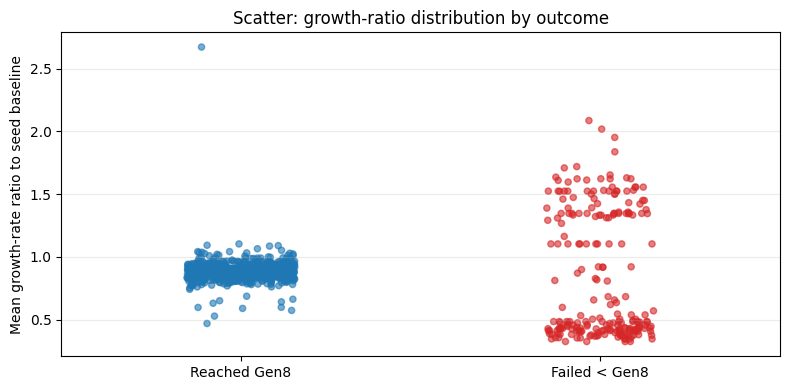

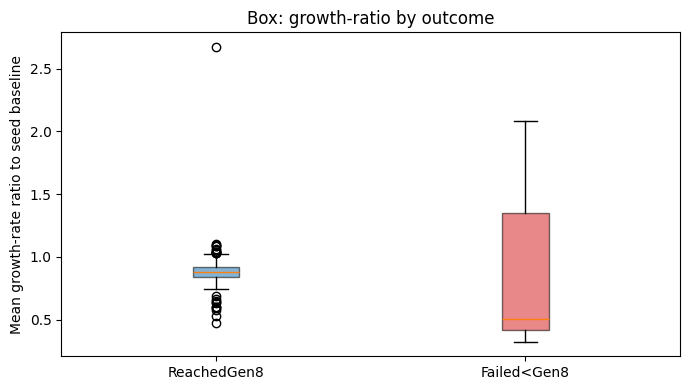

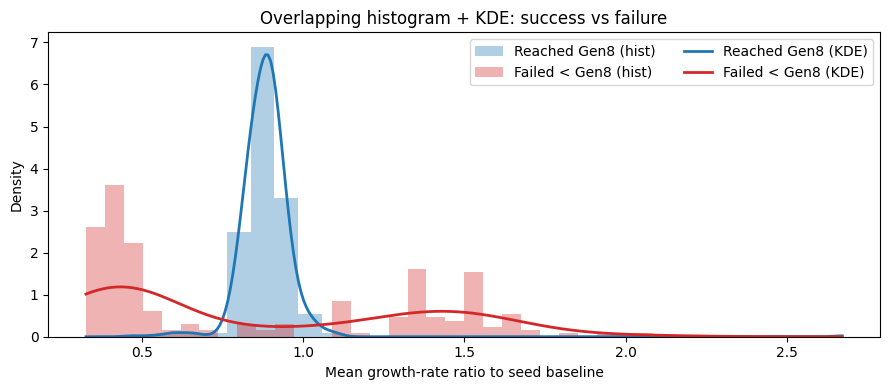

Saved: /user/home/il22158/work/vEcoli/surrogate/results/ko_runs_with_success_generation.csv


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

# -------------------------
# Paths from markdown "Data" section
# -------------------------
OUT_ROOT = Path('/user/home/il22158/work/vEcoli/out')
GENE_LIST_PATH = Path('/user/home/il22158/work/vEcoli/reading/imported/Single_KO_RNA_names.txt')
SUMMARY_FILE_PATHS = [
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_441_KOs_seed100_all.csv'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_441_KOs_seed101_all.csv'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_seed100_all.csv'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_seed101_all.csv'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_default_all.csv'),
]
OUT_DIR = Path('/user/home/il22158/work/vEcoli/surrogate/results')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# Load expected KO gene list (462 unique genes expected)
# -------------------------
gene_df = pd.read_csv(GENE_LIST_PATH, header=None, names=['gene_id'])
gene_df['gene_id'] = gene_df['gene_id'].astype(str).str.strip()
gene_df = gene_df[gene_df['gene_id'] != ''].drop_duplicates().reset_index(drop=True)
expected_ko_genes = gene_df['gene_id'].nunique()
print(f'Expected KO genes from list: {expected_ko_genes}')

# -------------------------
# Load ALL summary files and split KO rows + baseline rows
# -------------------------
all_frames = []
for fp in SUMMARY_FILE_PATHS:
    df = pd.read_csv(fp)
    df['source_file'] = fp.name
    all_frames.append(df)

all_df = pd.concat(all_frames, ignore_index=True)

# KO rows are in all four files according to markdown
ko_df = all_df[all_df['label'].astype(str).str.startswith('KO:')].copy()
ko_df['gene_id'] = ko_df['label'].astype(str).str.extract(r'KO:\s*([^,\s]+)')[0]
ko_df = ko_df.dropna(subset=['gene_id'])

# Keep KO genes that are present in the provided KO gene list
ko_df = ko_df[ko_df['gene_id'].isin(gene_df['gene_id'])].copy()
observed_ko_genes = ko_df['gene_id'].nunique()
print(f'Observed KO genes in summaries (after list filter): {observed_ko_genes}')
if observed_ko_genes != expected_ko_genes:
    missing = sorted(set(gene_df['gene_id']) - set(ko_df['gene_id']))
    print(f'Warning: {expected_ko_genes - observed_ko_genes} expected KO genes are missing from the loaded summaries.')
    print('First missing genes:', missing[:15])

# If lineage_seed is not present in csv, infer from source filename
if 'lineage_seed' not in ko_df.columns:
    ko_df['lineage_seed'] = ko_df['source_file'].str.extract(r'seed(\d+)')[0]
    ko_df.loc[ko_df['lineage_seed'].isna() & ko_df['source_file'].str.contains('default', case=False, na=False), 'lineage_seed'] = '0'
ko_df['lineage_seed'] = pd.to_numeric(ko_df['lineage_seed'], errors='coerce').astype('Int64')
ko_df = ko_df[ko_df['lineage_seed'].isin([100, 101])].copy() # exclude any non-seed or unexpected seeds for KO rows
ko_df['variant'] = pd.to_numeric(ko_df['variant'], errors='coerce').astype('Int64')

# -------------------------
# Baseline rows: strict selection from all_media_conditions* variant=0 label=baseline
# -------------------------
baseline_df = all_df.copy()
if 'lineage_seed' not in baseline_df.columns:
    baseline_df['lineage_seed'] = baseline_df['source_file'].str.extract(r'seed(\d+)')[0]
    baseline_df.loc[baseline_df['lineage_seed'].isna() & baseline_df['source_file'].str.contains('default', case=False, na=False), 'lineage_seed'] = '0'
else:
    inferred_seed = baseline_df['source_file'].str.extract(r'seed(\d+)')[0]
    baseline_df['lineage_seed'] = baseline_df['lineage_seed'].fillna(inferred_seed)
    baseline_df.loc[baseline_df['lineage_seed'].isna() & baseline_df['source_file'].str.contains('default', case=False, na=False), 'lineage_seed'] = '0'
baseline_df['lineage_seed'] = pd.to_numeric(baseline_df['lineage_seed'], errors='coerce')
baseline_df['variant'] = pd.to_numeric(baseline_df.get('variant'), errors='coerce')

label_series = baseline_df['label'].astype(str).str.strip().str.lower()
project_series = baseline_df['project'].astype(str).str.strip()
baseline_mask = (
    label_series.eq('baseline')
    & project_series.str.startswith('all_media_conditions')
    & baseline_df['variant'].eq(0)
)

baseline_df = baseline_df.loc[baseline_mask, ['lineage_seed', 'mean_growth_rate', 'project', 'variant', 'label']].copy()
if baseline_df.empty:
    raise RuntimeError(
        'No valid baseline rows found. Expected rows with label=baseline, project starting with all_media_conditions, and variant=0.'
    )

baseline_df = baseline_df.dropna(subset=['lineage_seed'])
baseline_df = baseline_df[baseline_df['lineage_seed'].isin([0, 100])].copy()
baseline_df = (
    baseline_df.groupby('lineage_seed', as_index=False)['mean_growth_rate']
    .mean()
    .rename(columns={'mean_growth_rate': 'seed_baseline_mean_growth_rate'})
)
baseline_rows = []
for seed in [0, 100]:
    values = baseline_df.loc[baseline_df['lineage_seed'] == seed, 'seed_baseline_mean_growth_rate']
    baseline_rows.append({'lineage_seed': seed, 'seed_baseline_mean_growth_rate': values.iloc[0] if len(values) > 0 else np.nan})
baseline_df = pd.DataFrame(baseline_rows)
if baseline_df['seed_baseline_mean_growth_rate'].isna().any():
    raise RuntimeError('Missing baseline rows for lineage_seed 0 and/or 100. Check baseline source files and labels.')
holistic_baseline_mean_growth_rate = float(baseline_df['seed_baseline_mean_growth_rate'].mean())

print('Table: baseline growth-rate reference by lineage seed (0 and 100).')
display(baseline_df)
print(f'Holistic baseline mean growth rate (mean of seeds 0 and 100): {holistic_baseline_mean_growth_rate:.6f}')

# Use one holistic baseline (mean of seeds 0 and 100) for all KO variants
ko_df['seed_baseline_mean_growth_rate'] = holistic_baseline_mean_growth_rate
ko_df['mean_growth_rate_ratio'] = ko_df['mean_growth_rate'] / ko_df['seed_baseline_mean_growth_rate']

missing_baseline = int(ko_df['seed_baseline_mean_growth_rate'].isna().sum())
if missing_baseline > 0:
    print(f'Warning: {missing_baseline} KO rows have no matched baseline seed; ratio is NaN for these rows.')

# -------------------------
# Filesystem-based success labeling (generation=8 folder existence)
# -------------------------
def generation_dir(project: str, variant: int, lineage_seed: int, generation: int) -> Path:
    return (
        OUT_ROOT
        / str(project)
        / 'success'
        / f'experiment_id={project}'
        / f'variant={int(variant)}'
        / f'lineage_seed={int(lineage_seed)}'
        / f'generation={int(generation)}'
    )

def max_existing_generation(project: str, variant: int, lineage_seed: int, max_gen: int = 8) -> int:
    for g in range(max_gen, 0, -1):
        if generation_dir(project, variant, lineage_seed, g).exists():
            return g
    return 0

def has_gen8_folder(project: str, variant: int, lineage_seed: int) -> int:
    return int(generation_dir(project, variant, lineage_seed, 8).exists())

key_cols = ['project', 'variant', 'lineage_seed']
run_keys = ko_df[key_cols].drop_duplicates().dropna().copy()
run_keys['project'] = run_keys['project'].astype(str)
run_keys['variant'] = run_keys['variant'].astype(int)
run_keys['lineage_seed'] = run_keys['lineage_seed'].astype(int)

run_keys['reached_gen8_by_folder'] = run_keys.apply(
    lambda r: has_gen8_folder(r['project'], r['variant'], r['lineage_seed']),
    axis=1,
 )
run_keys['max_success_generation'] = run_keys.apply(
    lambda r: max_existing_generation(r['project'], r['variant'], r['lineage_seed'], max_gen=8),
    axis=1,
 )
run_keys['failed_before_gen8'] = (run_keys['reached_gen8_by_folder'] == 0).astype(int)

ko_df = ko_df.merge(
    run_keys[['project', 'variant', 'lineage_seed', 'reached_gen8_by_folder', 'max_success_generation', 'failed_before_gen8']],
    on=['project', 'variant', 'lineage_seed'],
    how='left',
)

# Aggregate by gene for stable reporting
agg = (
    ko_df.groupby(['gene_id'], as_index=False)
    .agg(
        mean_growth_rate=('mean_growth_rate', 'mean'),
        mean_growth_rate_ratio=('mean_growth_rate_ratio', 'mean'),
        std_growth_rate=('mean_growth_rate', 'std'),
        failed_before_gen8=('failed_before_gen8', 'max'),
        fail_rate=('failed_before_gen8', 'mean'),
        n_runs=('gene_id', 'size'),
        mean_success_generation=('max_success_generation', 'mean'),
    )
)
agg['std_growth_rate'] = agg['std_growth_rate'].fillna(0.0)

print('Loaded KO rows:', len(ko_df))
print('Unique KO genes (final):', agg['gene_id'].nunique())
print('Runs with generation=8 folder:', int(run_keys['reached_gen8_by_folder'].sum()), '/', len(run_keys))
print('Failure rate (run-level):', round(ko_df['failed_before_gen8'].mean(), 4))
print('Failure rate (gene-level any-seed):', round(agg['failed_before_gen8'].mean(), 4))

print('Table: gene-level aggregate summary of KO growth and failure statistics across runs/seeds.')
display(agg.head(10))

# -------------------------
# Visual comparison before thresholding
# -------------------------
plot_df = ko_df[['mean_growth_rate_ratio', 'failed_before_gen8']].dropna().copy()
if plot_df.empty:
    raise RuntimeError('No valid growth-rate ratios were produced. Check baseline matching by lineage_seed.')
plot_df['failed_before_gen8'] = plot_df['failed_before_gen8'].astype(int)
plot_df['status'] = np.where(plot_df['failed_before_gen8'] == 1, 'Failed<Gen8', 'ReachedGen8')

group_stats = (
    plot_df.groupby('status')['mean_growth_rate_ratio']
    .agg(['count', 'mean', 'std', 'median', 'min', 'max'])
    .reset_index()
)
print('Table: run-level growth-rate ratio distribution summary for success vs failure groups.')
display(group_stats)

# Plot 1: scatter with centered groups + jitter
rng = np.random.default_rng(42)
centers = np.where(plot_df['failed_before_gen8'].values == 1, 0.2, -0.2)
x = centers + rng.uniform(-0.06, 0.06, size=len(plot_df))
plt.figure(figsize=(8, 4))
colors = np.where(plot_df['failed_before_gen8'].values == 1, '#d62728', '#1f77b4')
plt.scatter(x, plot_df['mean_growth_rate_ratio'].values, c=colors, alpha=0.6, s=20)
plt.xticks([-0.2, 0.2], ['Reached Gen8', 'Failed < Gen8'])
plt.xlim(-0.4, 0.4)
plt.ylabel('Mean growth-rate ratio to seed baseline')
plt.title('Scatter: growth-ratio distribution by outcome')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# Plot 2: box plot
ordered = group_stats.set_index('status').reindex(['ReachedGen8', 'Failed<Gen8']).reset_index()
plt.figure(figsize=(7, 4))
box_data = [
    plot_df.loc[plot_df['failed_before_gen8'] == 0, 'mean_growth_rate_ratio'].values,
    plot_df.loc[plot_df['failed_before_gen8'] == 1, 'mean_growth_rate_ratio'].values,
]
bp = plt.boxplot(box_data, tick_labels=['ReachedGen8', 'Failed<Gen8'], patch_artist=True)
bp['boxes'][0].set(facecolor='#1f77b4', alpha=0.55)
bp['boxes'][1].set(facecolor='#d62728', alpha=0.55)
plt.ylabel('Mean growth-rate ratio to seed baseline')
plt.title('Box: growth-ratio by outcome')
plt.tight_layout()
plt.show()

# Plot 3: overlapping histogram + KDE
ratio_success = plot_df.loc[plot_df['failed_before_gen8'] == 0, 'mean_growth_rate_ratio'].values
ratio_failed = plot_df.loc[plot_df['failed_before_gen8'] == 1, 'mean_growth_rate_ratio'].values
all_ratio = plot_df['mean_growth_rate_ratio'].values
xmin, xmax = float(np.nanmin(all_ratio)), float(np.nanmax(all_ratio))
x_grid = np.linspace(xmin, xmax, 300)[:, None]

def _kde_curve(values, x_grid_2d):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if len(values) < 2:
        return np.zeros(len(x_grid_2d), dtype=float)
    std = np.std(values, ddof=1) if len(values) > 1 else 0.0
    bw = 1.06 * std * (len(values) ** (-1 / 5)) if std > 0 else 0.05
    bw = max(float(bw), 1e-3)
    kde = KernelDensity(kernel='gaussian', bandwidth=bw)
    kde.fit(values.reshape(-1, 1))
    return np.exp(kde.score_samples(x_grid_2d))

plt.figure(figsize=(9, 4))
plt.hist(ratio_success, bins=30, density=True, alpha=0.35, color='#1f77b4', label='Reached Gen8 (hist)')
plt.hist(ratio_failed, bins=30, density=True, alpha=0.35, color='#d62728', label='Failed < Gen8 (hist)')
plt.plot(x_grid.ravel(), _kde_curve(ratio_success, x_grid), color='#1f77b4', linewidth=2, label='Reached Gen8 (KDE)')
plt.plot(x_grid.ravel(), _kde_curve(ratio_failed, x_grid), color='#d62728', linewidth=2, label='Failed < Gen8 (KDE)')
plt.xlabel('Mean growth-rate ratio to seed baseline')
plt.ylabel('Density')
plt.title('Overlapping histogram + KDE: success vs failure')
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

# Save output (single primary table)
ko_detail_path = OUT_DIR / 'ko_runs_with_success_generation.csv'
ko_df.to_csv(ko_detail_path, index=False)
print(f'Saved: {ko_detail_path}')

Table: run-level fold_change_mass distribution summary for success vs failure groups.


,status,count,mean,std,median,min,max
0,Failed<Gen8,222,6.233903,7.403566,1.282984,0.463922,30.857087
1,ReachedGen8,702,1.896317,0.450308,1.797149,0.840704,2.930225


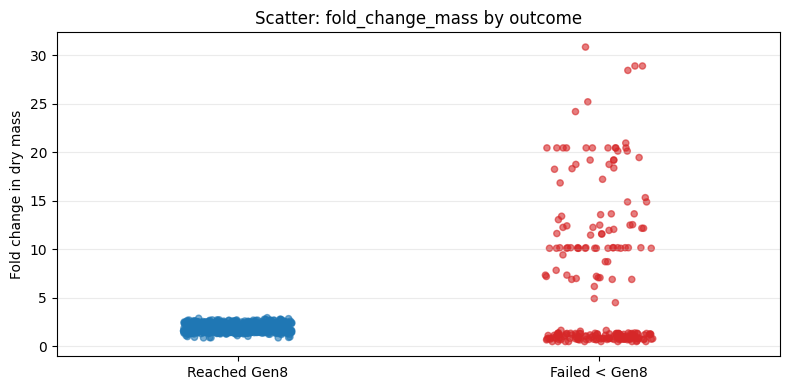

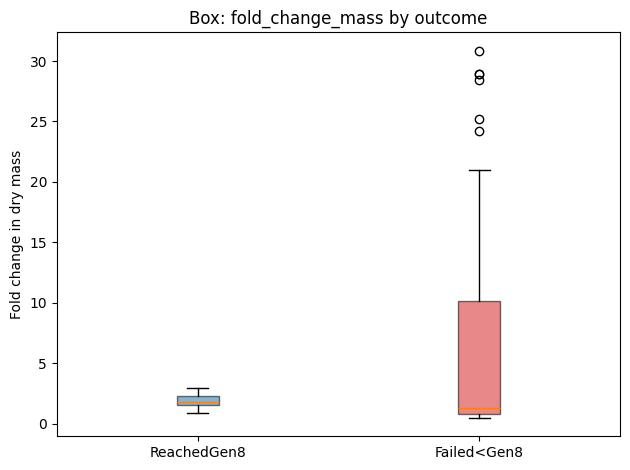

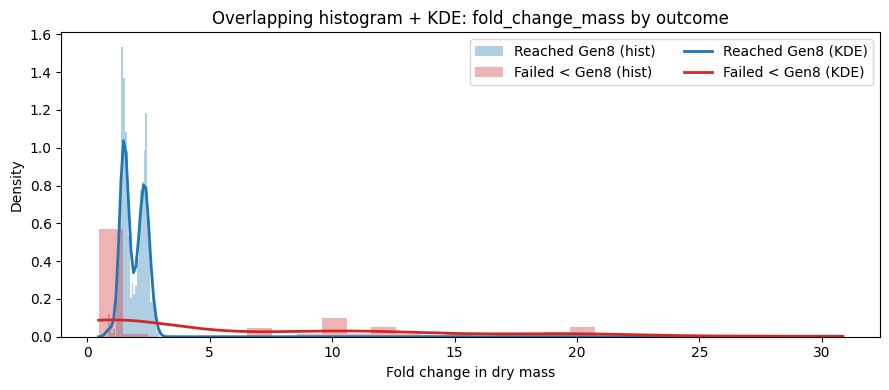

In [6]:
# Compare fold_change_mass between successful vs failed runs (same style as Cell 5)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

KO_DETAIL_PATH = Path('/user/home/il22158/work/vEcoli/surrogate/results/ko_runs_with_success_generation.csv')
df = pd.read_csv(KO_DETAIL_PATH)

# Validate required outcome label
if 'failed_before_gen8' not in df.columns:
    raise KeyError(f"Column 'failed_before_gen8' not found. Available columns: {list(df.columns)}")

# Use fold_change_mass directly when present; otherwise derive from dry-mass columns if possible
if 'fold_change_mass' in df.columns:
    metric = pd.to_numeric(df['fold_change_mass'], errors='coerce')
else:
    if {'final_dry_mass', 'initial_dry_mass'}.issubset(df.columns):
        final_mass = pd.to_numeric(df['final_dry_mass'], errors='coerce')
        initial_mass = pd.to_numeric(df['initial_dry_mass'], errors='coerce')
        metric = final_mass / initial_mass.replace(0, np.nan)
        print("Info: 'fold_change_mass' not present; derived as final_dry_mass / initial_dry_mass.")
    else:
        raise KeyError(
            "No 'fold_change_mass' column, and cannot derive it because 'final_dry_mass'/'initial_dry_mass' are missing. "
            f"Available columns: {list(df.columns)}"
        )

plot_df = pd.DataFrame({
    'fold_change_mass': metric,
    'failed_before_gen8': pd.to_numeric(df['failed_before_gen8'], errors='coerce')
})
plot_df = plot_df.dropna(subset=['fold_change_mass', 'failed_before_gen8']).copy()
plot_df = plot_df[np.isfinite(plot_df['fold_change_mass'])].copy()
plot_df['failed_before_gen8'] = plot_df['failed_before_gen8'].astype(int)
plot_df['status'] = np.where(plot_df['failed_before_gen8'] == 1, 'Failed<Gen8', 'ReachedGen8')

if plot_df.empty:
    raise RuntimeError('No valid fold_change_mass rows available after filtering.')

group_stats = (
    plot_df.groupby('status')['fold_change_mass']
    .agg(['count', 'mean', 'std', 'median', 'min', 'max'])
    .reset_index()
)
print('Table: run-level fold_change_mass distribution summary for success vs failure groups.')
display(group_stats)

# Plot 1: scatter with centered groups + jitter
rng = np.random.default_rng(42)
centers = np.where(plot_df['failed_before_gen8'].values == 1, 0.2, -0.2)
x = centers + rng.uniform(-0.06, 0.06, size=len(plot_df))
plt.figure(figsize=(8, 4))
colors = np.where(plot_df['failed_before_gen8'].values == 1, '#d62728', '#1f77b4')
plt.scatter(x, plot_df['fold_change_mass'].values, c=colors, alpha=0.6, s=20)
plt.xticks([-0.2, 0.2], ['Reached Gen8', 'Failed < Gen8'])
plt.xlim(-0.4, 0.4)
plt.ylabel('Fold change in dry mass')
plt.title('Scatter: fold_change_mass by outcome')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# Plot 2: box plot
box_data = [
    plot_df.loc[plot_df['failed_before_gen8'] == 0, 'fold_change_mass'].values,
    plot_df.loc[plot_df['failed_before_gen8'] == 1, 'fold_change_mass'].values,
]
bp = plt.boxplot(box_data, tick_labels=['ReachedGen8', 'Failed<Gen8'], patch_artist=True)
bp['boxes'][0].set(facecolor='#1f77b4', alpha=0.55)
bp['boxes'][1].set(facecolor='#d62728', alpha=0.55)
plt.ylabel('Fold change in dry mass')
plt.title('Box: fold_change_mass by outcome')
plt.tight_layout()
plt.show()

# Plot 3: overlapping histogram + KDE
fc_success = plot_df.loc[plot_df['failed_before_gen8'] == 0, 'fold_change_mass'].values
fc_failed = plot_df.loc[plot_df['failed_before_gen8'] == 1, 'fold_change_mass'].values
all_fc = plot_df['fold_change_mass'].values
xmin, xmax = float(np.nanmin(all_fc)), float(np.nanmax(all_fc))
x_grid = np.linspace(xmin, xmax, 300)[:, None]

def _kde_curve(values, x_grid_2d):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if len(values) < 2:
        return np.zeros(len(x_grid_2d), dtype=float)
    std = np.std(values, ddof=1) if len(values) > 1 else 0.0
    bw = 1.06 * std * (len(values) ** (-1 / 5)) if std > 0 else 0.05
    bw = max(float(bw), 1e-3)
    kde = KernelDensity(kernel='gaussian', bandwidth=bw)
    kde.fit(values.reshape(-1, 1))
    return np.exp(kde.score_samples(x_grid_2d))

plt.figure(figsize=(9, 4))
plt.hist(fc_success, bins=30, density=True, alpha=0.35, color='#1f77b4', label='Reached Gen8 (hist)')
plt.hist(fc_failed, bins=30, density=True, alpha=0.35, color='#d62728', label='Failed < Gen8 (hist)')
plt.plot(x_grid.ravel(), _kde_curve(fc_success, x_grid), color='#1f77b4', linewidth=2, label='Reached Gen8 (KDE)')
plt.plot(x_grid.ravel(), _kde_curve(fc_failed, x_grid), color='#d62728', linewidth=2, label='Failed < Gen8 (KDE)')
plt.xlabel('Fold change in dry mass')
plt.ylabel('Density')
plt.title('Overlapping histogram + KDE: fold_change_mass by outcome')
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

Table: summary of generation-normalized mass-change metric by outcome.


,status,count,mean,std,median,min,max
0,Failed<Gen8,224,1.143338,1.713636,0.059468,-0.089346,7.731989
1,ReachedGen8,721,0.111344,0.055799,0.096988,-0.019912,0.241278


Table: reference summary for geometric per-generation fold change by outcome.


,status,count,mean,std,median,min,max
0,Failed<Gen8,224,1.294793,0.415979,1.053069,0.879848,2.892329
1,ReachedGen8,721,1.079487,0.032624,1.074428,0.978544,1.143833


Using symlog scale for plots (linthresh=0.05).


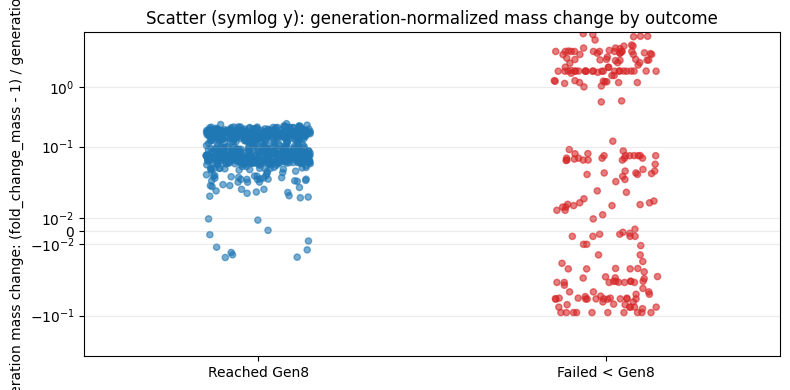

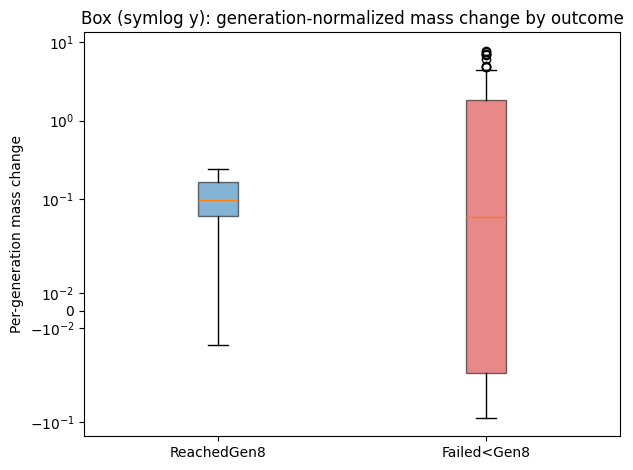

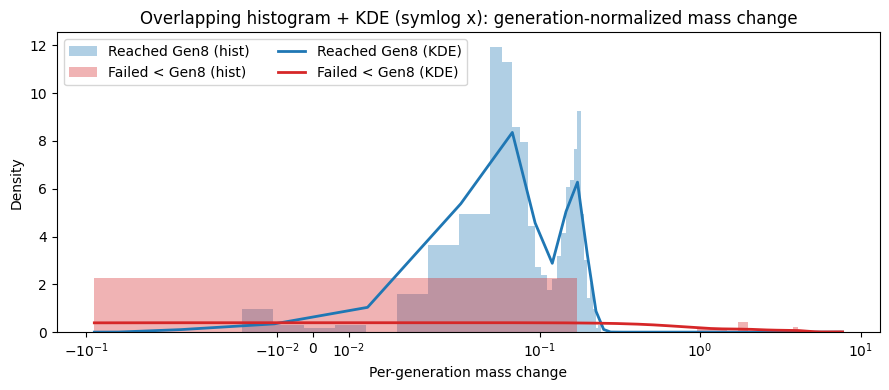

In [ ]:
# Compare generation-normalized mass change between successful vs failed runs
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

KO_DETAIL_PATH = Path('/user/home/il22158/work/vEcoli/surrogate/results/ko_runs_with_success_generation.csv')
df = pd.read_csv(KO_DETAIL_PATH)

required_cols = ['failed_before_gen8', 'max_success_generation']
for c in required_cols:
    if c not in df.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df.columns)}")

# Base total fold-change metric
if 'fold_change_mass' in df.columns:
    total_fc = pd.to_numeric(df['fold_change_mass'], errors='coerce')
elif {'final_dry_mass', 'initial_dry_mass'}.issubset(df.columns):
    final_mass = pd.to_numeric(df['final_dry_mass'], errors='coerce')
    initial_mass = pd.to_numeric(df['initial_dry_mass'], errors='coerce')
    total_fc = final_mass / initial_mass.replace(0, np.nan)
    print("Info: 'fold_change_mass' not present; derived as final_dry_mass / initial_dry_mass.")
else:
    raise KeyError(
        "No 'fold_change_mass' column, and cannot derive it because 'final_dry_mass'/'initial_dry_mass' are missing. "
        f"Available columns: {list(df.columns)}"
    )

# Generation count from run metadata
gen_count = pd.to_numeric(df['max_success_generation'], errors='coerce')
gen_count = gen_count.where(gen_count > 0, np.nan)

# User-requested normalization idea: divide total mass change by generation count
# total_mass_change = fold_change_mass - 1
per_gen_mass_change = (total_fc - 1.0) / gen_count

# Optional reference metric (geometric per-generation fold change)
per_gen_fc_geom = np.where(
    (total_fc > 0) & np.isfinite(total_fc) & np.isfinite(gen_count),
    np.power(total_fc, 1.0 / gen_count),
    np.nan,
 )

plot_df = pd.DataFrame({
    'per_gen_mass_change': per_gen_mass_change,
    'per_gen_fc_geom': per_gen_fc_geom,
    'fold_change_mass': total_fc,
    'generation_count': gen_count,
    'failed_before_gen8': pd.to_numeric(df['failed_before_gen8'], errors='coerce'),
})
plot_df = plot_df.dropna(subset=['per_gen_mass_change', 'failed_before_gen8']).copy()
plot_df = plot_df[np.isfinite(plot_df['per_gen_mass_change'])].copy()
plot_df['failed_before_gen8'] = plot_df['failed_before_gen8'].astype(int)
plot_df['status'] = np.where(plot_df['failed_before_gen8'] == 1, 'Failed<Gen8', 'ReachedGen8')

if plot_df.empty:
    raise RuntimeError('No valid rows available after filtering for per-generation mass change analysis.')

print('Table: summary of generation-normalized mass-change metric by outcome.')
group_stats = (
    plot_df.groupby('status')['per_gen_mass_change']
    .agg(['count', 'mean', 'std', 'median', 'min', 'max'])
    .reset_index()
)
display(group_stats)

print('Table: reference summary for geometric per-generation fold change by outcome.')
group_stats_geom = (
    plot_df.groupby('status')['per_gen_fc_geom']
    .agg(['count', 'mean', 'std', 'median', 'min', 'max'])
    .reset_index()
)
display(group_stats_geom)

# Signed log scaling compresses long tails while preserving negative values around zero
SYMLINTHRESH = 0.05
print(f'Using symlog scale for plots (linthresh={SYMLINTHRESH}).')

# Plot 1: scatter with centered groups + jitter
rng = np.random.default_rng(42)
centers = np.where(plot_df['failed_before_gen8'].values == 1, 0.2, -0.2)
x = centers + rng.uniform(-0.06, 0.06, size=len(plot_df))
plt.figure(figsize=(8, 4))
colors = np.where(plot_df['failed_before_gen8'].values == 1, '#d62728', '#1f77b4')
plt.scatter(x, plot_df['per_gen_mass_change'].values, c=colors, alpha=0.6, s=20)
plt.xticks([-0.2, 0.2], ['Reached Gen8', 'Failed < Gen8'])
plt.xlim(-0.4, 0.4)
plt.yscale('symlog', linthresh=SYMLINTHRESH)
plt.ylabel('Per-generation mass change: (fold_change_mass - 1) / generation_count')
plt.title('Scatter (symlog y): generation-normalized mass change by outcome')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# Plot 2: box plot
box_data = [
    plot_df.loc[plot_df['failed_before_gen8'] == 0, 'per_gen_mass_change'].values,
    plot_df.loc[plot_df['failed_before_gen8'] == 1, 'per_gen_mass_change'].values,
]
bp = plt.boxplot(box_data, tick_labels=['ReachedGen8', 'Failed<Gen8'], patch_artist=True)
bp['boxes'][0].set(facecolor='#1f77b4', alpha=0.55)
bp['boxes'][1].set(facecolor='#d62728', alpha=0.55)
plt.yscale('symlog', linthresh=SYMLINTHRESH)
plt.ylabel('Per-generation mass change')
plt.title('Box (symlog y): generation-normalized mass change by outcome')
plt.tight_layout()
plt.show()

# Plot 3: overlapping histogram + KDE
m_success = plot_df.loc[plot_df['failed_before_gen8'] == 0, 'per_gen_mass_change'].values
m_failed = plot_df.loc[plot_df['failed_before_gen8'] == 1, 'per_gen_mass_change'].values
all_m = plot_df['per_gen_mass_change'].values
xmin, xmax = float(np.nanmin(all_m)), float(np.nanmax(all_m))
x_grid = np.linspace(xmin, xmax, 300)[:, None]

def _kde_curve(values, x_grid_2d):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if len(values) < 2:
        return np.zeros(len(x_grid_2d), dtype=float)
    std = np.std(values, ddof=1) if len(values) > 1 else 0.0
    bw = 1.06 * std * (len(values) ** (-1 / 5)) if std > 0 else 0.05
    bw = max(float(bw), 1e-3)
    kde = KernelDensity(kernel='gaussian', bandwidth=bw)
    kde.fit(values.reshape(-1, 1))
    return np.exp(kde.score_samples(x_grid_2d))

plt.figure(figsize=(9, 4))
plt.hist(m_success, bins=30, density=True, alpha=0.35, color='#1f77b4', label='Reached Gen8 (hist)')
plt.hist(m_failed, bins=30, density=True, alpha=0.35, color='#d62728', label='Failed < Gen8 (hist)')
plt.plot(x_grid.ravel(), _kde_curve(m_success, x_grid), color='#1f77b4', linewidth=2, label='Reached Gen8 (KDE)')
plt.plot(x_grid.ravel(), _kde_curve(m_failed, x_grid), color='#d62728', linewidth=2, label='Failed < Gen8 (KDE)')
plt.xscale('symlog', linthresh=SYMLINTHRESH)
plt.xlabel('Per-generation mass change')
plt.ylabel('Density')
plt.title('Overlapping histogram + KDE (symlog x): generation-normalized mass change')
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

## Analyse with time-series data instead of data summaries

- Full data:

/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed100_all.parquet
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed101_all.parquet
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed101_all.parquet

### pq data format inspection

In [7]:
# Inspect pq time-series structure before preprocessing
from pathlib import Path
import pandas as pd

TIMESERIES_PATHS = [
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed101_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed101_all.parquet'),
]

print('PQ files to inspect:')
for p in TIMESERIES_PATHS:
    print('-', p)

schema_rows = []

for p in TIMESERIES_PATHS:
    if not p.exists():
        print(f'Warning: missing file: {p}')
        continue

    df = pd.read_parquet(p)
    n_rows, n_cols = df.shape
    cols = list(df.columns)

    print('\n' + '=' * 90)
    print(f'File: {p.name}')
    print(f'Shape: {n_rows} rows x {n_cols} columns')
    print('Columns:')
    print(cols)
    print('Dtypes:')
    print(df.dtypes.astype(str))

    key_cols = [
        c for c in [
            'project', 'experiment_id', 'variant', 'lineage_seed', 'seed', 'generation',
            'time', 'label', 'listeners__mass__instantaneous_growth_rate', 'listeners__mass__dry_mass'
        ] if c in df.columns
    ]
    if key_cols:
        print('Sample rows (key columns):')
        display(df[key_cols].head(5))
    else:
        print('Sample rows (first 5):')
        display(df.head(5))

    # Show ALL time points for one simulation in this file
    run_id_cols = [c for c in ['project', 'variant', 'label'] if c in df.columns]
    if ('time' in df.columns) and run_id_cols:
        run_key = df[run_id_cols].drop_duplicates().iloc[0]
        run_mask = pd.Series(True, index=df.index)
        for c in run_id_cols:
            run_mask &= df[c].astype(str) == str(run_key[c])
        run_times = pd.to_numeric(df.loc[run_mask, 'time'], errors='coerce').dropna().drop_duplicates().sort_values().reset_index(drop=True)

        print('One simulation used for full time-point display:')
        print({c: str(run_key[c]) for c in run_id_cols})
        print(f'Total unique time points for this simulation: {len(run_times)}')
        display(pd.DataFrame({'time': run_times}))

    row = {'file': p.name, 'n_rows': n_rows, 'n_cols': n_cols}
    for c in cols:
        row[f'has::{c}'] = 1
    schema_rows.append(row)

if not schema_rows:
    raise RuntimeError('No parquet files were loaded. Check TIMESERIES_PATHS.')

schema_df = pd.DataFrame(schema_rows).fillna(0)
has_cols = sorted([c for c in schema_df.columns if c.startswith('has::')])

print('\n' + '=' * 90)
print('Schema presence matrix (1=present, 0=absent):')
display(schema_df[['file', 'n_rows', 'n_cols'] + has_cols])

print('Column coverage summary across files:')
coverage = pd.DataFrame({
    'column': [c.replace('has::', '') for c in has_cols],
    'files_with_column': [int(schema_df[c].sum()) for c in has_cols],
    'total_files': [len(schema_df)] * len(has_cols),
})
coverage['all_files'] = coverage['files_with_column'] == coverage['total_files']
display(coverage.sort_values(['all_files', 'column'], ascending=[True, True]).reset_index(drop=True))

# Load merged frame for quick global checks
parts = []
for p in TIMESERIES_PATHS:
    if p.exists():
        x = pd.read_parquet(p).copy()
        x['source_file'] = p.name
        parts.append(x)
ts = pd.concat(parts, ignore_index=True)

print('\nMerged pq shape:', ts.shape)
print('Merged columns:', list(ts.columns))

for c in ['project', 'experiment_id', 'variant', 'lineage_seed', 'seed', 'generation', 'time', 'label']:
    if c in ts.columns:
        print(f'Unique non-null {c}:', int(ts[c].dropna().nunique()))

if 'time' in ts.columns:
    t = pd.to_numeric(ts['time'], errors='coerce')
    print('Time min/max:', float(t.min()), float(t.max()))

print('\nDone: use this structure info to finalize preprocessing assumptions.')

PQ files to inspect:
- /user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed100_all.parquet
- /user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed101_all.parquet
- /user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet
- /user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed101_all.parquet

File: growth_rate_timeseries_441_KOs_seed100_all.parquet
Shape: 29944 rows x 6 columns
Columns:
['project', 'variant', 'label', 'time', 'listeners__mass__instantaneous_growth_rate', 'listeners__mass__dry_mass']
Dtypes:
project                                        object
variant                                         int64
label                                          object
time                                          float64
listeners__mass__instantaneous_growth_rate    float64
listeners__mass__dry_mass                     float64
dty

,project,variant,time,label,listeners__mass__instantaneous_growth_rate,listeners__mass__dry_mass
0,gene_ko_441imported_2seeds,1,0.0,KO: EG10109,0.000000,266.982849
1,gene_ko_441imported_2seeds,1,400.0,KO: EG10109,0.000182,289.433248
2,gene_ko_441imported_2seeds,1,800.0,KO: EG10109,0.000253,317.276584
3,gene_ko_441imported_2seeds,1,1200.0,KO: EG10109,0.000313,354.977569
4,gene_ko_441imported_2seeds,1,1600.0,KO: EG10109,0.000300,400.173977


One simulation used for full time-point display:
{'project': 'gene_ko_441imported_2seeds', 'variant': '1', 'label': 'KO: EG10109'}
Total unique time points for this simulation: 69


,time
0,0.0
1,400.0
2,800.0
3,1200.0
4,1600.0
...,...
64,24288.0
65,24688.0
66,25088.0
67,25488.0



File: growth_rate_timeseries_441_KOs_seed101_all.parquet
Shape: 27357 rows x 6 columns
Columns:
['project', 'variant', 'label', 'time', 'listeners__mass__instantaneous_growth_rate', 'listeners__mass__dry_mass']
Dtypes:
project                                        object
variant                                         int64
label                                          object
time                                          float64
listeners__mass__instantaneous_growth_rate    float64
listeners__mass__dry_mass                     float64
dtype: object
Sample rows (key columns):


...


Schema presence matrix (1=present, 0=absent):


,file,n_rows,n_cols,has::label,has::listeners__mass__dry_mass,has::listeners__mass__instantaneous_growth_rate,has::project,has::time,has::variant
0,growth_rate_timeseries_441_KOs_seed100_all.par...,29944,6,1,1,1,1,1,1
1,growth_rate_timeseries_441_KOs_seed101_all.par...,27357,6,1,1,1,1,1,1
2,growth_rate_timeseries_seed100_all.parquet,56096,6,1,1,1,1,1,1
3,growth_rate_timeseries_seed101_all.parquet,46577,6,1,1,1,1,1,1


Column coverage summary across files:


,column,files_with_column,total_files,all_files
0,label,4,4,True
1,listeners__mass__dry_mass,4,4,True
2,listeners__mass__instantaneous_growth_rate,4,4,True
3,project,4,4,True
4,time,4,4,True
5,variant,4,4,True



Merged pq shape: (159974, 7)
Merged columns: ['project', 'variant', 'label', 'time', 'listeners__mass__instantaneous_growth_rate', 'listeners__mass__dry_mass', 'source_file']
Unique non-null project: 5
Unique non-null variant: 442
Unique non-null time: 25029
Unique non-null label: 486
Time min/max: 0.0 48214.0

Done: use this structure info to finalize preprocessing assumptions.


### plot individual simulation growth rates

Number of simulations that stop at generation 7: 21
Info: generation column missing in parquet; inferred generation from time resets within each run.
Plotting first 10 run(s).
Info: showing time-based trajectories because generation values collapsed to single points in parquet data.


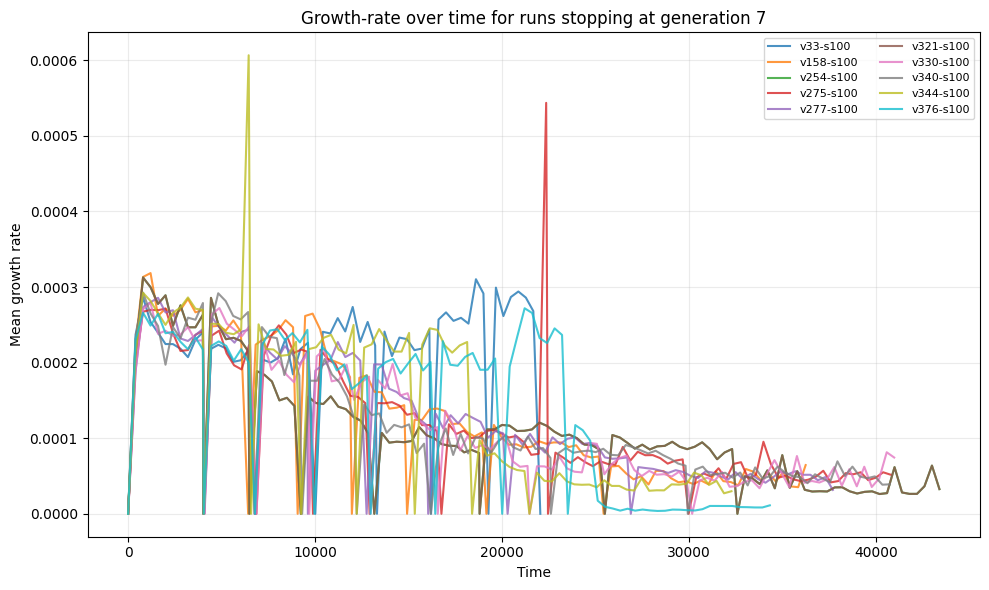

In [4]:
# Inspect runs that stop at generation 7 and plot growth-rate trajectories
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

KO_DETAIL_PATH = Path('/user/home/il22158/work/vEcoli/surrogate/results/ko_runs_with_success_generation.csv')
TIMESERIES_PATHS = [
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed101_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed101_all.parquet'),
]

def pick_col(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f'None of candidate columns found: {candidates}. Available columns: {list(df.columns)}')
    return None

# Load stop-7 run keys from saved KO detail table
run_df = pd.read_csv(KO_DETAIL_PATH)
run_keys = run_df[['project', 'variant', 'lineage_seed', 'max_success_generation']].drop_duplicates().copy()
run_keys['variant'] = pd.to_numeric(run_keys['variant'], errors='coerce').astype('Int64')
run_keys['lineage_seed'] = pd.to_numeric(run_keys['lineage_seed'], errors='coerce').astype('Int64')
run_keys['max_success_generation'] = pd.to_numeric(run_keys['max_success_generation'], errors='coerce').astype('Int64')
run_keys = run_keys.dropna(subset=['project', 'variant', 'lineage_seed', 'max_success_generation'])
run_keys = run_keys[run_keys['lineage_seed'].isin([100, 101])].copy() # exclude any non-seed or unexpected seeds for KO rows

stop7_runs = run_keys[run_keys['max_success_generation'] == 7].copy()
n_stop7 = len(stop7_runs)
print(f'Number of simulations that stop at generation 7: {n_stop7}')

if n_stop7 == 0:
    print('No generation-7 stop simulations found.')
else:
    # Load all extracted timeseries data
    ts_parts = []
    for p in TIMESERIES_PATHS:
        part = pd.read_parquet(p)
        part['source_file'] = p.name
        ts_parts.append(part)
    ts = pd.concat(ts_parts, ignore_index=True)

    # Resolve essential columns dynamically (robust to schema changes)
    col_project = pick_col(ts, ['project', 'experiment_id'], required=False)
    col_variant = pick_col(ts, ['variant'])
    col_seed = pick_col(ts, ['lineage_seed', 'seed'], required=False)
    col_generation = pick_col(ts, ['generation'], required=False)
    col_growth = pick_col(ts, [
        'mean_growth_rate',
        'listeners__mass__instantaneous_growth_rate',
        'instantaneous_growth_rate',
        'growth_rate',
    ])
    col_time = pick_col(ts, ['time'], required=False)

    # Fallback: extract lineage seed from project text when no explicit seed column exists
    if col_seed is None:
        project_text = ts[col_project].astype(str) if col_project is not None else pd.Series('', index=ts.index)
        source_text = ts['source_file'].astype(str) if 'source_file' in ts.columns else pd.Series('', index=ts.index)
        ts['_lineage_seed_from_project'] = project_text.str.extract(r'seed(?:=|_)?(\d+)')[0]
        ts['_lineage_seed_from_project'] = ts['_lineage_seed_from_project'].fillna(project_text.str.extract(r'lineage_seed(?:=|_)?(\d+)')[0])
        ts['_lineage_seed_from_project'] = ts['_lineage_seed_from_project'].fillna(source_text.str.extract(r'seed(?:=|_)?(\d+)')[0])
        default_mask = project_text.str.contains('default', case=False, na=False) | source_text.str.contains('default', case=False, na=False)
        ts.loc[ts['_lineage_seed_from_project'].isna() & default_mask, '_lineage_seed_from_project'] = '0'
        if ts['_lineage_seed_from_project'].isna().all():
            raise KeyError('No seed column found and could not infer seed from project/experiment_id or source_file names.')
        col_seed = '_lineage_seed_from_project'

    # Fallback: infer generation from time resets when parquet has no generation column
    if col_generation is None:
        if col_time is None:
            raise KeyError('No generation column found, and no time column available to infer generation.')
        ts[col_time] = pd.to_numeric(ts[col_time], errors='coerce')
        run_group_cols = [col_variant, col_seed]
        if col_project is not None:
            run_group_cols.append(col_project)
        ts['_generation_from_time'] = (
            ts.groupby(run_group_cols, dropna=False)[col_time]
            .transform(lambda s: np.cumsum(s.diff().fillna(0) < 0) + 1)
        )
        col_generation = '_generation_from_time'
        print('Info: generation column missing in parquet; inferred generation from time resets within each run.')

    ts[col_variant] = pd.to_numeric(ts[col_variant], errors='coerce')
    ts[col_seed] = pd.to_numeric(ts[col_seed], errors='coerce')
    ts[col_generation] = pd.to_numeric(ts[col_generation], errors='coerce')
    ts[col_growth] = pd.to_numeric(ts[col_growth], errors='coerce')

    if col_time is not None:
        ts[col_time] = pd.to_numeric(ts[col_time], errors='coerce')

    # Keep only rows with usable keys and growth values
    required_cols = [col_variant, col_seed, col_generation, col_growth]
    if col_time is not None:
        required_cols.append(col_time)
    ts = ts.dropna(subset=required_cols).copy()

    to_plot = stop7_runs.head(10).copy()
    print(f'Plotting first {len(to_plot)} run(s).')

    plt.figure(figsize=(10, 6))
    plotted = 0
    used_time_axis = False

    for _, row in to_plot.reset_index(drop=True).iterrows():
        project = str(row['project'])
        variant = int(row['variant'])
        seed = int(row['lineage_seed'])

        mask = (ts[col_variant].astype(int) == variant) & (ts[col_seed].astype(int) == seed)
        if col_project is not None:
            mask &= (ts[col_project].astype(str) == project)

        run_cols = [col_generation, col_growth]
        if col_time is not None:
            run_cols.append(col_time)
        run_ts = ts.loc[mask, run_cols].copy()
        if run_ts.empty:
            continue

        gen_curve = (
            run_ts.groupby(col_generation, as_index=False)[col_growth]
            .mean()
            .sort_values(col_generation)
        )

        # Plot only generations up to 7 for this analysis
        gen_curve = gen_curve[gen_curve[col_generation] <= 7]
        if (not gen_curve.empty) and (gen_curve[col_generation].nunique() > 1):
            plotted += 1
            plt.plot(
                gen_curve[col_generation].values,
                gen_curve[col_growth].values,
                marker='o',
                linewidth=1.5,
                alpha=0.8,
                label=f'v{variant}-s{seed}'
            )
            continue

        # If generation collapses to one value, fallback to time-based trajectory
        if col_time is not None:
            time_curve = (
                run_ts.groupby(col_time, as_index=False)[col_growth]
                .mean()
                .sort_values(col_time)
            )
            if not time_curve.empty and time_curve[col_time].nunique() > 1:
                used_time_axis = True
                plotted += 1
                plt.plot(
                    time_curve[col_time].values,
                    time_curve[col_growth].values,
                    linewidth=1.5,
                    alpha=0.8,
                    label=f'v{variant}-s{seed}'
                )

    if used_time_axis:
        plt.xlabel('Time')
        plt.title('Growth-rate over time for runs stopping at generation 7')
        print('Info: showing time-based trajectories because generation values collapsed to single points in parquet data.')
    else:
        plt.xlabel('Generation')
        plt.title('Growth-rate over generation for runs stopping at generation 7')
        plt.xticks(range(1, 8))
    plt.ylabel('Mean growth rate')
    plt.grid(alpha=0.25)
    if plotted > 0:
        plt.legend(fontsize=8, ncol=2)
    else:
        print('No trajectories plotted from extracted timeseries parquet files. Check key-column matching.')
    plt.tight_layout()
    plt.show()

Number of simulations that reach generation 8: 702
Info: generation column missing in parquet; inferred generation from time resets within each run.
Plotting first 10 run(s).
Info: showing time-based trajectories because generation values collapsed to single points in parquet data.


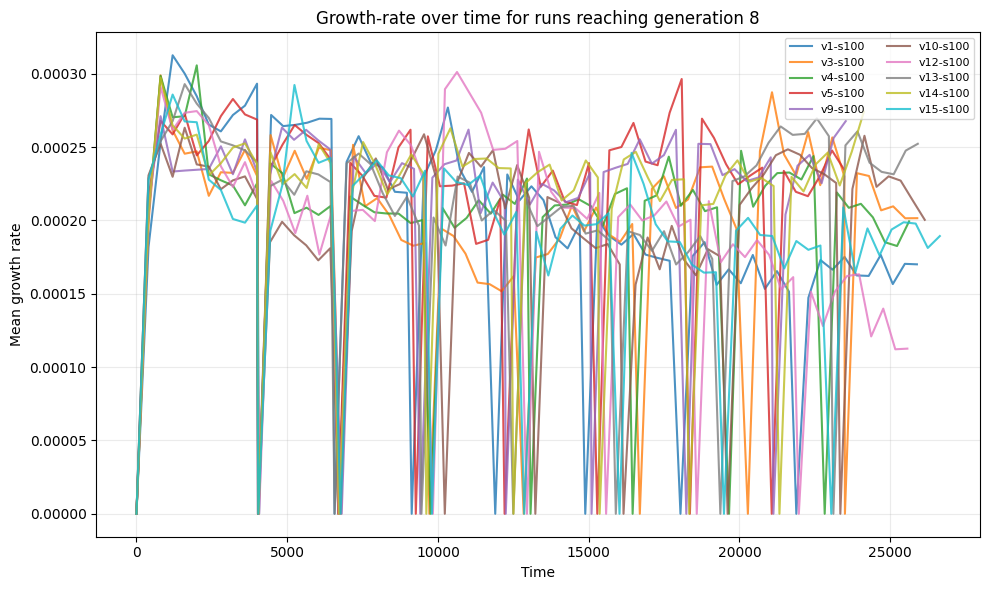

In [2]:
# Inspect runs that successfully reach generation 8 and plot growth-rate trajectories
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

KO_DETAIL_PATH = Path('/user/home/il22158/work/vEcoli/surrogate/results/ko_runs_with_success_generation.csv')
TIMESERIES_PATHS = [
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed101_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed101_all.parquet'),
]

def pick_col(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f'None of candidate columns found: {candidates}. Available columns: {list(df.columns)}')
    return None

# Load run keys from saved KO detail table
run_df = pd.read_csv(KO_DETAIL_PATH)
run_keys = run_df[['project', 'variant', 'lineage_seed', 'max_success_generation']].drop_duplicates().copy()
run_keys['variant'] = pd.to_numeric(run_keys['variant'], errors='coerce').astype('Int64')
run_keys['lineage_seed'] = pd.to_numeric(run_keys['lineage_seed'], errors='coerce').astype('Int64')
run_keys['max_success_generation'] = pd.to_numeric(run_keys['max_success_generation'], errors='coerce').astype('Int64')
run_keys = run_keys.dropna(subset=['project', 'variant', 'lineage_seed', 'max_success_generation'])
run_keys = run_keys[run_keys['lineage_seed'].isin([100, 101])].copy() # exclude any non-seed or unexpected seeds for KO rows

reach8_runs = run_keys[run_keys['max_success_generation'] >= 8].copy()
n_reach8 = len(reach8_runs)
print(f'Number of simulations that reach generation 8: {n_reach8}')

if n_reach8 == 0:
    print('No generation-8-success simulations found.')
else:
    # Load all extracted timeseries data
    ts_parts = []
    for p in TIMESERIES_PATHS:
        part = pd.read_parquet(p)
        part['source_file'] = p.name
        ts_parts.append(part)
    ts = pd.concat(ts_parts, ignore_index=True)

    # Resolve essential columns dynamically (robust to schema changes)
    col_project = pick_col(ts, ['project', 'experiment_id'], required=False)
    col_variant = pick_col(ts, ['variant'])
    col_seed = pick_col(ts, ['lineage_seed', 'seed'], required=False)
    col_generation = pick_col(ts, ['generation'], required=False)
    col_growth = pick_col(ts, [
        'mean_growth_rate',
        'listeners__mass__instantaneous_growth_rate',
        'instantaneous_growth_rate',
        'growth_rate',
    ])
    col_time = pick_col(ts, ['time'], required=False)

    # Fallback: extract lineage seed from project/source text when no explicit seed column exists
    if col_seed is None:
        project_text = ts[col_project].astype(str) if col_project is not None else pd.Series('', index=ts.index)
        source_text = ts['source_file'].astype(str) if 'source_file' in ts.columns else pd.Series('', index=ts.index)
        ts['_lineage_seed_from_project'] = project_text.str.extract(r'seed(?:=|_)?(\d+)')[0]
        ts['_lineage_seed_from_project'] = ts['_lineage_seed_from_project'].fillna(project_text.str.extract(r'lineage_seed(?:=|_)?(\d+)')[0])
        ts['_lineage_seed_from_project'] = ts['_lineage_seed_from_project'].fillna(source_text.str.extract(r'seed(?:=|_)?(\d+)')[0])
        default_mask = project_text.str.contains('default', case=False, na=False) | source_text.str.contains('default', case=False, na=False)
        ts.loc[ts['_lineage_seed_from_project'].isna() & default_mask, '_lineage_seed_from_project'] = '0'
        if ts['_lineage_seed_from_project'].isna().all():
            raise KeyError('No seed column found and could not infer seed from project/experiment_id or source_file names.')
        col_seed = '_lineage_seed_from_project'

    # Fallback: infer generation from time resets when parquet has no generation column
    if col_generation is None:
        if col_time is None:
            raise KeyError('No generation column found, and no time column available to infer generation.')
        ts[col_time] = pd.to_numeric(ts[col_time], errors='coerce')
        run_group_cols = [col_variant, col_seed]
        if col_project is not None:
            run_group_cols.append(col_project)
        ts['_generation_from_time'] = (
            ts.groupby(run_group_cols, dropna=False)[col_time]
            .transform(lambda s: np.cumsum(s.diff().fillna(0) < 0) + 1)
        )
        col_generation = '_generation_from_time'
        print('Info: generation column missing in parquet; inferred generation from time resets within each run.')

    ts[col_variant] = pd.to_numeric(ts[col_variant], errors='coerce')
    ts[col_seed] = pd.to_numeric(ts[col_seed], errors='coerce')
    ts[col_generation] = pd.to_numeric(ts[col_generation], errors='coerce')
    ts[col_growth] = pd.to_numeric(ts[col_growth], errors='coerce')
    if col_time is not None:
        ts[col_time] = pd.to_numeric(ts[col_time], errors='coerce')

    # Keep only rows with usable keys and growth values
    required_cols = [col_variant, col_seed, col_generation, col_growth]
    if col_time is not None:
        required_cols.append(col_time)
    ts = ts.dropna(subset=required_cols).copy()

    to_plot = reach8_runs.head(10).copy()
    print(f'Plotting first {len(to_plot)} run(s).')

    plt.figure(figsize=(10, 6))
    plotted = 0
    used_time_axis = False

    for _, row in to_plot.reset_index(drop=True).iterrows():
        project = str(row['project'])
        variant = int(row['variant'])
        seed = int(row['lineage_seed'])

        mask = (ts[col_variant].astype(int) == variant) & (ts[col_seed].astype(int) == seed)
        if col_project is not None:
            mask &= (ts[col_project].astype(str) == project)

        run_cols = [col_generation, col_growth]
        if col_time is not None:
            run_cols.append(col_time)
        run_ts = ts.loc[mask, run_cols].copy()
        if run_ts.empty:
            continue

        gen_curve = (
            run_ts.groupby(col_generation, as_index=False)[col_growth]
            .mean()
            .sort_values(col_generation)
        )

        # Plot only generations up to 8 for this analysis
        gen_curve = gen_curve[gen_curve[col_generation] <= 8]
        if (not gen_curve.empty) and (gen_curve[col_generation].nunique() > 1):
            plotted += 1
            plt.plot(
                gen_curve[col_generation].values,
                gen_curve[col_growth].values,
                marker='o',
                linewidth=1.5,
                alpha=0.8,
                label=f'v{variant}-s{seed}'
            )
            continue

        # If generation collapses to one value, fallback to time-based trajectory
        if col_time is not None:
            time_curve = (
                run_ts.groupby(col_time, as_index=False)[col_growth]
                .mean()
                .sort_values(col_time)
            )
            if not time_curve.empty and time_curve[col_time].nunique() > 1:
                used_time_axis = True
                plotted += 1
                plt.plot(
                    time_curve[col_time].values,
                    time_curve[col_growth].values,
                    linewidth=1.5,
                    alpha=0.8,
                    label=f'v{variant}-s{seed}'
                )

    if used_time_axis:
        plt.xlabel('Time')
        plt.title('Growth-rate over time for runs reaching generation 8')
        print('Info: showing time-based trajectories because generation values collapsed to single points in parquet data.')
    else:
        plt.xlabel('Generation')
        plt.title('Growth-rate over generation for runs reaching generation 8')
        plt.xticks(range(1, 9))
    plt.ylabel('Mean growth rate')
    plt.grid(alpha=0.25)
    if plotted > 0:
        plt.legend(fontsize=8, ncol=2)
    else:
        print('No trajectories plotted from extracted timeseries parquet files. Check key-column matching.')
    plt.tight_layout()
    plt.show()

Number of simulations that fail within first 1-3 generations: 7
Info: generation column missing in parquet; inferred generation from time resets within each run.
Plotting first 7 run(s).
Info: showing time-based trajectories because generation values collapsed to single points in parquet data.


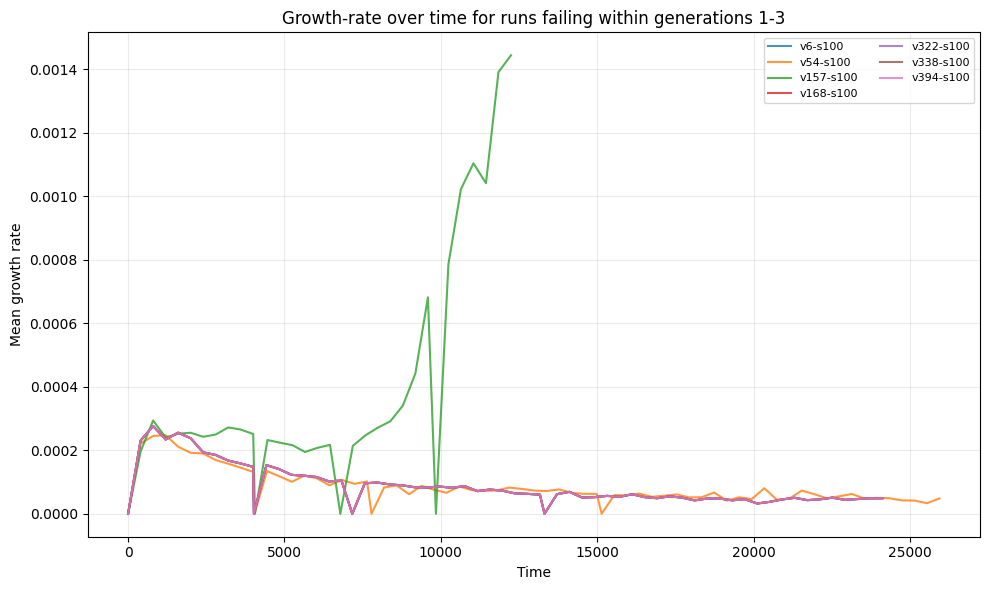

In [3]:
# Inspect runs that fail in the first 1-2 generations and plot growth-rate trajectories
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

KO_DETAIL_PATH = Path('/user/home/il22158/work/vEcoli/surrogate/results/ko_runs_with_success_generation.csv')
TIMESERIES_PATHS = [
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed101_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed101_all.parquet'),
]

def pick_col(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f'None of candidate columns found: {candidates}. Available columns: {list(df.columns)}')
    return None

# Load run keys from saved KO detail table
run_df = pd.read_csv(KO_DETAIL_PATH)
run_keys = run_df[['project', 'variant', 'lineage_seed', 'max_success_generation']].drop_duplicates().copy()
run_keys['variant'] = pd.to_numeric(run_keys['variant'], errors='coerce').astype('Int64')
run_keys['lineage_seed'] = pd.to_numeric(run_keys['lineage_seed'], errors='coerce').astype('Int64')
run_keys['max_success_generation'] = pd.to_numeric(run_keys['max_success_generation'], errors='coerce').astype('Int64')
run_keys = run_keys.dropna(subset=['project', 'variant', 'lineage_seed', 'max_success_generation'])
run_keys = run_keys[run_keys['lineage_seed'].isin([100, 101])].copy() # exclude any non-seed or unexpected seeds for KO rows

early_fail_runs = run_keys[run_keys['max_success_generation'].between(1, 3)].copy()
n_early_fail = len(early_fail_runs)
print(f'Number of simulations that fail within first 1-3 generations: {n_early_fail}')

if n_early_fail == 0:
    print('No early-failure (gen 1-3) simulations found.')
else:
    # Load all extracted timeseries data
    ts_parts = []
    for p in TIMESERIES_PATHS:
        part = pd.read_parquet(p)
        part['source_file'] = p.name
        ts_parts.append(part)
    ts = pd.concat(ts_parts, ignore_index=True)

    # Resolve essential columns dynamically (robust to schema changes)
    col_project = pick_col(ts, ['project', 'experiment_id'], required=False)
    col_variant = pick_col(ts, ['variant'])
    col_seed = pick_col(ts, ['lineage_seed', 'seed'], required=False)
    col_generation = pick_col(ts, ['generation'], required=False)
    col_growth = pick_col(ts, [
        'mean_growth_rate',
        'listeners__mass__instantaneous_growth_rate',
        'instantaneous_growth_rate',
        'growth_rate',
    ])
    col_time = pick_col(ts, ['time'], required=False)

    # Fallback: extract lineage seed from project text when no explicit seed column exists
    if col_seed is None:
        project_text = ts[col_project].astype(str) if col_project is not None else pd.Series('', index=ts.index)
        source_text = ts['source_file'].astype(str) if 'source_file' in ts.columns else pd.Series('', index=ts.index)
        ts['_lineage_seed_from_project'] = project_text.str.extract(r'seed(?:=|_)?(\d+)')[0]
        ts['_lineage_seed_from_project'] = ts['_lineage_seed_from_project'].fillna(project_text.str.extract(r'lineage_seed(?:=|_)?(\d+)')[0])
        ts['_lineage_seed_from_project'] = ts['_lineage_seed_from_project'].fillna(source_text.str.extract(r'seed(?:=|_)?(\d+)')[0])
        default_mask = project_text.str.contains('default', case=False, na=False) | source_text.str.contains('default', case=False, na=False)
        ts.loc[ts['_lineage_seed_from_project'].isna() & default_mask, '_lineage_seed_from_project'] = '0'
        if ts['_lineage_seed_from_project'].isna().all():
            raise KeyError('No seed column found and could not infer seed from project/experiment_id or source_file names.')
        col_seed = '_lineage_seed_from_project'

    # Fallback: infer generation from time resets when parquet has no generation column
    if col_generation is None:
        if col_time is None:
            raise KeyError('No generation column found, and no time column available to infer generation.')
        ts[col_time] = pd.to_numeric(ts[col_time], errors='coerce')
        run_group_cols = [col_variant, col_seed]
        if col_project is not None:
            run_group_cols.append(col_project)
        ts['_generation_from_time'] = (
            ts.groupby(run_group_cols, dropna=False)[col_time]
            .transform(lambda s: np.cumsum(s.diff().fillna(0) < 0) + 1)
        )
        col_generation = '_generation_from_time'
        print('Info: generation column missing in parquet; inferred generation from time resets within each run.')

    ts[col_variant] = pd.to_numeric(ts[col_variant], errors='coerce')
    ts[col_seed] = pd.to_numeric(ts[col_seed], errors='coerce')
    ts[col_generation] = pd.to_numeric(ts[col_generation], errors='coerce')
    ts[col_growth] = pd.to_numeric(ts[col_growth], errors='coerce')

    if col_time is not None:
        ts[col_time] = pd.to_numeric(ts[col_time], errors='coerce')

    # Keep only rows with usable keys and growth values
    required_cols = [col_variant, col_seed, col_generation, col_growth]
    if col_time is not None:
        required_cols.append(col_time)
    ts = ts.dropna(subset=required_cols).copy()

    to_plot = early_fail_runs.head(10).copy()
    print(f'Plotting first {len(to_plot)} run(s).')

    plt.figure(figsize=(10, 6))
    plotted = 0
    used_time_axis = False

    for _, row in to_plot.reset_index(drop=True).iterrows():
        project = str(row['project'])
        variant = int(row['variant'])
        seed = int(row['lineage_seed'])

        mask = (ts[col_variant].astype(int) == variant) & (ts[col_seed].astype(int) == seed)
        if col_project is not None:
            mask &= (ts[col_project].astype(str) == project)

        run_cols = [col_generation, col_growth]
        if col_time is not None:
            run_cols.append(col_time)
        run_ts = ts.loc[mask, run_cols].copy()
        if run_ts.empty:
            continue

        gen_curve = (
            run_ts.groupby(col_generation, as_index=False)[col_growth]
            .mean()
            .sort_values(col_generation)
        )

        # Plot only generations up to 2 for this early-failure analysis
        gen_curve = gen_curve[gen_curve[col_generation] <= 2]
        if (not gen_curve.empty) and (gen_curve[col_generation].nunique() > 1):
            plotted += 1
            plt.plot(
                gen_curve[col_generation].values,
                gen_curve[col_growth].values,
                marker='o',
                linewidth=1.5,
                alpha=0.8,
                label=f'v{variant}-s{seed}'
            )
            continue

        # If generation collapses to one value, fallback to time-based trajectory
        if col_time is not None:
            time_curve = (
                run_ts.groupby(col_time, as_index=False)[col_growth]
                .mean()
                .sort_values(col_time)
            )
            if not time_curve.empty and time_curve[col_time].nunique() > 1:
                used_time_axis = True
                plotted += 1
                plt.plot(
                    time_curve[col_time].values,
                    time_curve[col_growth].values,
                    linewidth=1.5,
                    alpha=0.8,
                    label=f'v{variant}-s{seed}'
                )

    if used_time_axis:
        plt.xlabel('Time')
        plt.title('Growth-rate over time for runs failing within generations 1-3')
        print('Info: showing time-based trajectories because generation values collapsed to single points in parquet data.')
    else:
        plt.xlabel('Generation')
        plt.title('Growth-rate over generation for runs failing within generations 1-3')
        plt.xticks([1, 2, 3])
    plt.ylabel('Mean growth rate')
    plt.grid(alpha=0.25)
    if plotted > 0:
        plt.legend(fontsize=8, ncol=2)
    else:
        print('No trajectories plotted from extracted timeseries parquet files. Check key-column matching.')
    plt.tight_layout()
    plt.show()

Seed 100 runs failing at generations 1-3: 7
Matched seed 101 runs for those KO variants: 7
Info: generation column missing in parquet; inferred generation from time resets within each run.
Plotting first 7 matched seed-101 run(s).
Info: showing time-based trajectories because generation values collapsed to single points in parquet data.


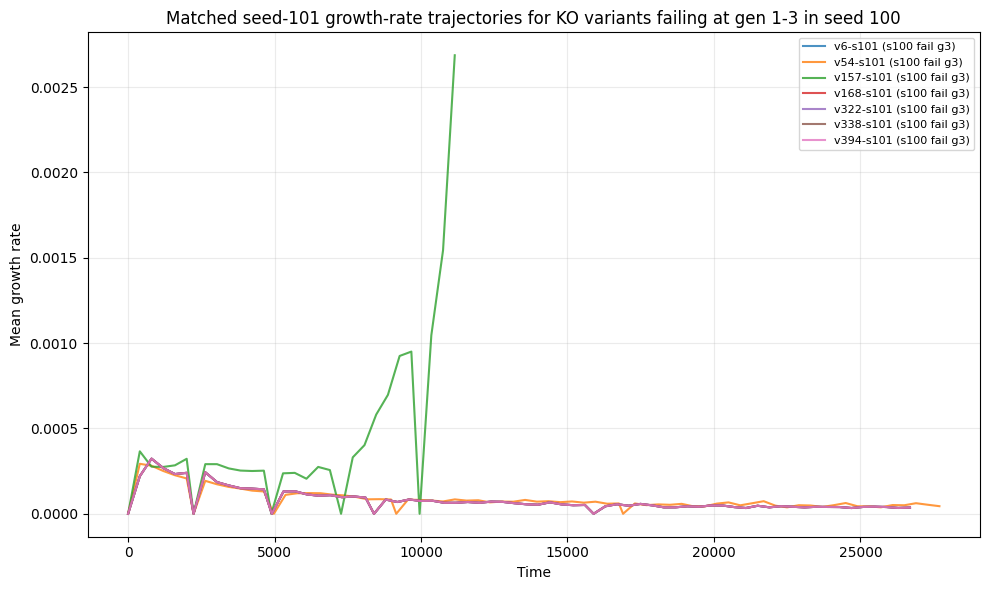

In [5]:
# Plot the same KO simulations in seed 101 for variants that fail at generations 1-3 in seed 100
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

KO_DETAIL_PATH = Path('/user/home/il22158/work/vEcoli/surrogate/results/ko_runs_with_success_generation.csv')
TIMESERIES_PATHS = [
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed101_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed101_all.parquet'),
]

def pick_col(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f'None of candidate columns found: {candidates}. Available columns: {list(df.columns)}')
    return None

# Load run keys from saved KO detail table
run_df = pd.read_csv(KO_DETAIL_PATH)
run_keys = run_df[['project', 'variant', 'lineage_seed', 'max_success_generation']].drop_duplicates().copy()
run_keys['variant'] = pd.to_numeric(run_keys['variant'], errors='coerce').astype('Int64')
run_keys['lineage_seed'] = pd.to_numeric(run_keys['lineage_seed'], errors='coerce').astype('Int64')
run_keys['max_success_generation'] = pd.to_numeric(run_keys['max_success_generation'], errors='coerce').astype('Int64')
run_keys = run_keys.dropna(subset=['project', 'variant', 'lineage_seed', 'max_success_generation'])
run_keys = run_keys[run_keys['lineage_seed'].isin([100, 101])].copy() # exclude any non-seed or unexpected seeds for KO rows

# Source set: failures at generations 1-3 on seed 100
seed100_fail_1to3 = run_keys[
    (run_keys['lineage_seed'] == 100)
    & (run_keys['max_success_generation'].between(1, 3))
].copy()

print(f'Seed 100 runs failing at generations 1-3: {len(seed100_fail_1to3)}')
if seed100_fail_1to3.empty:
    print('No seed-100 failures in generations 1-3 found.')
else:
    # Match same project+variant on seed 101
    target_pairs = seed100_fail_1to3[['project', 'variant', 'max_success_generation']].copy()
    target_pairs = target_pairs.rename(columns={'max_success_generation': 'seed100_fail_generation'})

    seed101_runs = run_keys[run_keys['lineage_seed'] == 101].copy()
    matched_seed101 = seed101_runs.merge(
        target_pairs[['project', 'variant', 'seed100_fail_generation']],
        on=['project', 'variant'],
        how='inner',
    )

    print(f'Matched seed 101 runs for those KO variants: {len(matched_seed101)}')

    if matched_seed101.empty:
        print('No matching seed-101 runs found for the selected seed-100 early-failure variants.')
    else:
        # Load all extracted timeseries data
        ts_parts = []
        for p in TIMESERIES_PATHS:
            part = pd.read_parquet(p)
            part['source_file'] = p.name
            ts_parts.append(part)
        ts = pd.concat(ts_parts, ignore_index=True)

        # Resolve essential columns dynamically (robust to schema changes)
        col_project = pick_col(ts, ['project', 'experiment_id'], required=False)
        col_variant = pick_col(ts, ['variant'])
        col_seed = pick_col(ts, ['lineage_seed', 'seed'], required=False)
        col_generation = pick_col(ts, ['generation'], required=False)
        col_growth = pick_col(ts, [
            'mean_growth_rate',
            'listeners__mass__instantaneous_growth_rate',
            'instantaneous_growth_rate',
            'growth_rate',
        ])
        col_time = pick_col(ts, ['time'], required=False)

        # Fallback: extract lineage seed from project/source text when no explicit seed column exists
        if col_seed is None:
            project_text = ts[col_project].astype(str) if col_project is not None else pd.Series('', index=ts.index)
            source_text = ts['source_file'].astype(str) if 'source_file' in ts.columns else pd.Series('', index=ts.index)
            ts['_lineage_seed_from_project'] = project_text.str.extract(r'seed(?:=|_)?(\d+)')[0]
            ts['_lineage_seed_from_project'] = ts['_lineage_seed_from_project'].fillna(project_text.str.extract(r'lineage_seed(?:=|_)?(\d+)')[0])
            ts['_lineage_seed_from_project'] = ts['_lineage_seed_from_project'].fillna(source_text.str.extract(r'seed(?:=|_)?(\d+)')[0])
            default_mask = project_text.str.contains('default', case=False, na=False) | source_text.str.contains('default', case=False, na=False)
            ts.loc[ts['_lineage_seed_from_project'].isna() & default_mask, '_lineage_seed_from_project'] = '0'
            if ts['_lineage_seed_from_project'].isna().all():
                raise KeyError('No seed column found and could not infer seed from project/experiment_id or source_file names.')
            col_seed = '_lineage_seed_from_project'

        # Fallback: infer generation from time resets when parquet has no generation column
        if col_generation is None:
            if col_time is None:
                raise KeyError('No generation column found, and no time column available to infer generation.')
            ts[col_time] = pd.to_numeric(ts[col_time], errors='coerce')
            run_group_cols = [col_variant, col_seed]
            if col_project is not None:
                run_group_cols.append(col_project)
            ts['_generation_from_time'] = (
                ts.groupby(run_group_cols, dropna=False)[col_time]
                .transform(lambda s: np.cumsum(s.diff().fillna(0) < 0) + 1)
            )
            col_generation = '_generation_from_time'
            print('Info: generation column missing in parquet; inferred generation from time resets within each run.')

        ts[col_variant] = pd.to_numeric(ts[col_variant], errors='coerce')
        ts[col_seed] = pd.to_numeric(ts[col_seed], errors='coerce')
        ts[col_generation] = pd.to_numeric(ts[col_generation], errors='coerce')
        ts[col_growth] = pd.to_numeric(ts[col_growth], errors='coerce')

        if col_time is not None:
            ts[col_time] = pd.to_numeric(ts[col_time], errors='coerce')

        # Keep only rows with usable keys and growth values
        required_cols = [col_variant, col_seed, col_generation, col_growth]
        if col_time is not None:
            required_cols.append(col_time)
        ts = ts.dropna(subset=required_cols).copy()

        to_plot = matched_seed101.head(10).copy()
        print(f'Plotting first {len(to_plot)} matched seed-101 run(s).')

        plt.figure(figsize=(10, 6))
        plotted = 0
        used_time_axis = False

        for _, row in to_plot.reset_index(drop=True).iterrows():
            project = str(row['project'])
            variant = int(row['variant'])
            seed = int(row['lineage_seed'])
            seed100_fail_gen = int(row['seed100_fail_generation'])

            mask = (ts[col_variant].astype(int) == variant) & (ts[col_seed].astype(int) == seed)
            if col_project is not None:
                mask &= (ts[col_project].astype(str) == project)

            run_cols = [col_generation, col_growth]
            if col_time is not None:
                run_cols.append(col_time)
            run_ts = ts.loc[mask, run_cols].copy()
            if run_ts.empty:
                continue

            gen_curve = (
                run_ts.groupby(col_generation, as_index=False)[col_growth]
                .mean()
                .sort_values(col_generation)
            )

            # For matched seed-101 runs, show trajectory up to generation 8 for direct comparison
            gen_curve = gen_curve[gen_curve[col_generation] <= 8]
            if (not gen_curve.empty) and (gen_curve[col_generation].nunique() > 1):
                plotted += 1
                plt.plot(
                    gen_curve[col_generation].values,
                    gen_curve[col_growth].values,
                    marker='o',
                    linewidth=1.5,
                    alpha=0.8,
                    label=f'v{variant}-s101 (s100 fail g{seed100_fail_gen})'
                )
                continue

            # If generation collapses to one value, fallback to time-based trajectory
            if col_time is not None:
                time_curve = (
                    run_ts.groupby(col_time, as_index=False)[col_growth]
                    .mean()
                    .sort_values(col_time)
                )
                if not time_curve.empty and time_curve[col_time].nunique() > 1:
                    used_time_axis = True
                    plotted += 1
                    plt.plot(
                        time_curve[col_time].values,
                        time_curve[col_growth].values,
                        linewidth=1.5,
                        alpha=0.8,
                        label=f'v{variant}-s101 (s100 fail g{seed100_fail_gen})'
                    )

        if used_time_axis:
            plt.xlabel('Time')
            plt.title('Matched seed-101 growth-rate trajectories for KO variants failing at gen 1-3 in seed 100')
            print('Info: showing time-based trajectories because generation values collapsed to single points in parquet data.')
        else:
            plt.xlabel('Generation')
            plt.title('Matched seed-101 growth-rate trajectories for KO variants failing at gen 1-3 in seed 100')
            plt.xticks(range(1, 9))
        plt.ylabel('Mean growth rate')
        plt.grid(alpha=0.25)
        if plotted > 0:
            plt.legend(fontsize=8, ncol=1)
        else:
            print('No trajectories plotted from extracted timeseries parquet files. Check key-column matching.')
        plt.tight_layout()
        plt.show()

Fact check: the seed 101 with same knockout also failed to proceed to 8th generation, but the failure happens at 4th generation instead.


# Logic about building ML surrogate

For this surrogate, the target is derived from pq time-series dry-mass trajectories rather than summary CSV growth averages. This aligns with simulation mechanics: advancement to the next generation is driven by mass accumulation, so per-generation dry-mass fold change is directly tied to viability and growth dynamics.

## Notation and target construction
Let run $i$ have a maximum horizon of $G=8$ generations.

- $M_{i,g}^{\text{start}}$: dry mass at start of generation $g$
- $M_{i,g}^{\text{end}}$: dry mass at end of generation $g$
- Per-generation fold change:
$$f_{i,g}=\frac{M_{i,g}^{\text{end}}}{M_{i,g}^{\text{start}}}$$
- Log fold change:
$$z_{i,g}=\log f_{i,g}$$

If the run reaches only $n_i<8$ generations (early termination), define a fixed penalty fold change $f_{\text{pen}}\in(0,1]$ for missing generations, with $z_{\text{pen}}=\log(f_{\text{pen}})$.
The horizon-normalized scalar target is then
$$\bar z_i=\frac{1}{G}\left(\sum_{g=1}^{n_i} z_{i,g}+\sum_{g=n_i+1}^{G} z_{\text{pen}}\right), \qquad y_i=\exp(\bar z_i).$$

Interpretation: $y_i$ is an effective per-generation fold-change score over a fixed 8-generation horizon, where early failure is encoded through penalty-filled missing generations.

## Why this form is useful
- Multiplicative growth becomes additive in log space, making aggregation stable and interpretable.
- A fixed horizon gives targets comparable across runs with different stopping points.
- Penalty-filling keeps a single scalar regression target while still encoding failure severity.

## Suggested training target
Use $\bar z_i$ (log-space target) for regression, then map back with $\hat y_i=\exp(\hat z_i)$ for interpretation.
A simple weighted objective is
$$\mathcal{L}=\frac{1}{N}\sum_{i=1}^{N} w_i\,(\hat z_i-\bar z_i)^2,\quad w_i=1+\lambda\,\mathbf{1}[n_i<8],$$
where $\lambda\ge 0$ increases emphasis on failed runs if needed.

## Notes on censoring semantics
Early-terminated runs are effectively right-censored with respect to full-horizon growth potential. The penalty-fill approach is a pragmatic surrogate-target design that preserves single-output simplicity while reflecting censoring/failure information.

## References
- Box, G. E. P., and Cox, D. R. (1964). An Analysis of Transformations. Journal of the Royal Statistical Society, Series B.
- Cox, D. R. (1972). Regression Models and Life-Tables. Journal of the Royal Statistical Society, Series B.
- Kalbfleisch, J. D., and Prentice, R. L. (2002). The Statistical Analysis of Failure Time Data (2nd ed.).

# New Data Preprocessing

**Data**
- gene list:
/user/home/il22158/work/vEcoli/reading/imported/Single_KO_RNA_names.txt

- Time-series data
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed100_all.parquet
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed101_all.parquet
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed101_all.parquet; /user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_default_all.parquet
- explanation:
1. the single-knockout variants are saved in first four timeseries files, and the baseline simulation are the one labelled as baseline under "all media conditions..." simulation folder.
2. 2 baseline simulation (wildtype) can be found in /user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_seed100_all.csv and /user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_default_all.csv.

## Code testing
Coverted to function - preprocess.py

In [ ]:
# Prototype conversion: rebuild generation labels for one variant using raw filename endpoints
from pathlib import Path
import numpy as np
import pandas as pd

# ----------
# 1) Choose one run to test (editable)
# ----------
project = 'gene_ko_441imported_2seeds'
variant = 6
lineage_seed = 101

OUT_ROOT = Path('/user/home/il22158/work/vEcoli/out')
RAW_BASE = OUT_ROOT / project / 'history' / f'experiment_id={project}' / f'variant={variant}' / f'lineage_seed={lineage_seed}'
TIMESERIES_PATHS = [
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed101_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed101_all.parquet'),
]

# ----------
# 2) Parse generation endpoint hints from raw filenames
# ----------
raw_rows = []
for p in RAW_BASE.glob('generation=*/agent_id=*/**/*.pq'):
    gen_token = [x for x in p.parts if x.startswith('generation=')]
    if not gen_token:
        continue
    g = int(gen_token[0].split('=')[1])
    # Stem is the last recorded step index in that generation
    step_idx = pd.to_numeric(p.stem, errors='coerce')
    if pd.isna(step_idx):
        continue
    raw_rows.append({'generation': g, 'step_idx_hint': float(step_idx), 'raw_file': str(p)})

raw_meta = pd.DataFrame(raw_rows)
if raw_meta.empty:
    raise RuntimeError(f'No raw generation pq files found under: {RAW_BASE}')

# Keep one representative endpoint per generation (max step index if duplicates exist)
raw_meta = (
    raw_meta.groupby('generation', as_index=False)['step_idx_hint']
    .max()
    .sort_values('generation')
    .reset_index(drop=True)
)

# Calibrate simulation dt from one raw generation file (fallback to 20.0)
first_raw = next(RAW_BASE.glob('generation=*/agent_id=*/**/*.pq'))
first_df = pd.read_parquet(first_raw)
if 'time' in first_df.columns and len(first_df) >= 2:
    t = pd.to_numeric(first_df['time'], errors='coerce').dropna().values
    dt = float(np.nanmedian(np.diff(t))) if len(t) >= 2 else 20.0
    if not np.isfinite(dt) or dt <= 0:
        dt = 20.0
else:
    dt = 20.0

# Convert step-index hints to within-generation end-time hints
raw_meta['gen_end_time_hint'] = (raw_meta['step_idx_hint'] - 1.0) * dt
raw_meta['cum_end_time_hint'] = raw_meta['gen_end_time_hint'].cumsum()
raw_meta['cum_start_time_hint'] = raw_meta['cum_end_time_hint'].shift(fill_value=0.0)

print('Raw generation endpoint hints for selected run:')
display(raw_meta)
print(f'Estimated dt from raw pq = {dt:.3f}')

# ----------
# 3) Load saved extracted pq and isolate this run
# ----------
parts = []
for p in TIMESERIES_PATHS:
    x = pd.read_parquet(p).copy()
    x['source_file'] = p.name
    parts.append(x)
saved = pd.concat(parts, ignore_index=True)

# In saved pq, seed is not explicit; use source file to split seed100/seed101 rows
seed_token = f'seed{lineage_seed}'
saved_run = saved[
    (saved['project'].astype(str) == project)
    & (pd.to_numeric(saved['variant'], errors='coerce') == variant)
    & (saved['source_file'].astype(str).str.contains(seed_token, case=False, na=False))
].copy()

if saved_run.empty:
    raise RuntimeError('No matching rows found in saved pq for selected project/variant/seed token.')

saved_run['time'] = pd.to_numeric(saved_run['time'], errors='coerce')
saved_run['growth_rate'] = pd.to_numeric(saved_run['listeners__mass__instantaneous_growth_rate'], errors='coerce')
saved_run['dry_mass'] = pd.to_numeric(saved_run['listeners__mass__dry_mass'], errors='coerce')
saved_run = saved_run.dropna(subset=['time', 'growth_rate', 'dry_mass']).sort_values('time').reset_index(drop=True)

print(f'Saved rows selected: {len(saved_run)}')
print(f"Saved time range: {saved_run['time'].min():.3f} to {saved_run['time'].max():.3f}")

# ----------
# 4) Reconstruct generation from cumulative endpoint hints
# ----------
bin_edges = np.r_[0.0, raw_meta['cum_end_time_hint'].values]
gen_labels = np.arange(1, len(bin_edges))

# Small tolerance handles slight extraction offsets
tol = max(2.5 * dt, 50.0)
bin_edges_tol = bin_edges.copy()
bin_edges_tol[-1] = bin_edges_tol[-1] + tol

saved_run['generation_reconstructed'] = pd.cut(
    saved_run['time'],
    bins=bin_edges_tol,
    labels=gen_labels,
    include_lowest=True,
    right=True,
).astype('Int64')

# ----------
# 5) Build surrogate-ready per-generation features for this one run
# ----------
gen_table = (
    saved_run.dropna(subset=['generation_reconstructed'])
    .groupby('generation_reconstructed', as_index=False)
    .agg(
        start_time=('time', 'min'),
        end_time=('time', 'max'),
        n_points=('time', 'size'),
        growth_mean=('growth_rate', 'mean'),
        dry_mass_start=('dry_mass', 'first'),
        dry_mass_end=('dry_mass', 'last'),
    )
    .sort_values('generation_reconstructed')
    .reset_index(drop=True)
)
gen_table['fold_change_mass'] = gen_table['dry_mass_end'] / gen_table['dry_mass_start'].replace(0, np.nan)
gen_table['log_fold_change_mass'] = np.log(gen_table['fold_change_mass'])

print('Reconstructed per-generation table (prototype for surrogate input):')
display(gen_table)

# Optional wide format for a single-row surrogate feature target preview
wide = gen_table[['generation_reconstructed', 'growth_mean', 'fold_change_mass', 'log_fold_change_mass']].copy()
wide = wide.set_index('generation_reconstructed')
wide.columns = [f'{c}_g{{}}'.format('') for c in wide.columns]
wide_out = wide.T
print('Wide preview (single-run feature/target style):')
display(wide_out)

Raw generation endpoint hints for selected run:


,generation,step_idx_hint,gen_end_time_hint,cum_end_time_hint,cum_start_time_hint
0,1,112.0,2220.0,2220.0,0.0
1,2,134.0,2660.0,4880.0,2220.0
2,3,175.0,3480.0,8360.0,4880.0
3,4,375.0,7480.0,15840.0,8360.0
4,5,541.0,10800.0,26640.0,15840.0


Estimated dt from raw pq = 20.000
Saved rows selected: 69
Saved time range: 0.000 to 26693.000
Reconstructed per-generation table (prototype for surrogate input):


,generation_reconstructed,start_time,end_time,n_points,growth_mean,dry_mass_start,dry_mass_end,fold_change_mass,log_fold_change_mass
0,1,0.0,2000.0,6,0.000214,411.038504,696.662962,1.694885,0.527615
1,2,2235.0,4635.0,7,0.000148,371.372644,573.037570,1.543026,0.433745
2,3,4906.0,8106.0,9,0.000098,297.461478,428.465929,1.440408,0.364926
3,4,8395.0,15595.0,19,0.000062,219.673786,359.796603,1.637868,0.493395
4,5,15893.0,26293.0,27,0.000041,183.252674,287.830148,1.570674,0.451505


Wide preview (single-run feature/target style):


generation_reconstructed,1,2,3,4,5
growth_mean_g,0.000214,0.000148,0.000098,0.000062,0.000041
fold_change_mass_g,1.694885,1.543026,1.440408,1.637868,1.570674
log_fold_change_mass_g,0.527615,0.433745,0.364926,0.493395,0.451505


# Baseline Model